<a href="https://colab.research.google.com/github/Sowmya-BH/ML-Projects/blob/main/AmazonDeliveryTimePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Summary**-


# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


# **General Guidelines** : -  

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [3]:
pip install inflection # used when renaming columns in subsection 1.1

In [4]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.3 MB/s eta 0:00:00


In [5]:
!pip install scikit-posthocs

In [6]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
import math
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scikit_posthocs import posthoc_dunn
import scikit_posthocs as sp

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                            f1_score, precision_score, recall_score, log_loss,
                            roc_auc_score, ConfusionMatrixDisplay)

import inflection # used when renaming columns

In [7]:
# Define bold and reset codes
# BOLD = "\033[1m"
# RESET = "\033[0m"
def print_bold(text):
    print(f"\033[1m{text}\033[0m")

In [8]:
# Set maximum columns to display
pd.set_option('display.max_columns', 60)  # Show only 3 columns

# # Reset to default
# pd.reset_option('display.max_columns')

# Set maximum rows to display
pd.set_option('display.max_rows', 100)  # Show only 10 rows
# pd.reset_option('display.max_rows')

### Dataset Loading

In [9]:
df = pd.read_csv('/content/amazon_delivery.csv')
df

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,Windy,High,motorcycle,Metropolitian,160,Home
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,20:10:00,Windy,Jam,motorcycle,Metropolitian,180,Jewelry
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,Cloudy,Low,scooter,Metropolitian,80,Home
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,Cloudy,High,motorcycle,Metropolitian,130,Kitchen


In [10]:
# Dataset First Look
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


### Dataset Rows & Columns count

In [11]:
# Dataset Rows & Columns count
# Basic info
print_bold("===== Shape =====")
print(df.shape)

print_bold("\n===== Column Names =====")
print(df.columns)

===== Shape =====
(43739, 16)

===== Column Names =====
Index(['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude',
       'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date',
       'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area',
       'Delivery_Time', 'Category'],
      dtype='object')


### Dataset Information

In [12]:
# Dataset Info
print_bold("\n===== Data Types =====")
print(df.dtypes)


===== Data Types =====
Order_ID            object
Agent_Age            int64
Agent_Rating       float64
Store_Latitude     float64
Store_Longitude    float64
Drop_Latitude      float64
Drop_Longitude     float64
Order_Date          object
Order_Time          object
Pickup_Time         object
Weather             object
Traffic             object
Vehicle             object
Area                object
Delivery_Time        int64
Category            object
dtype: object


#### Duplicate Values

In [13]:
# Dataset Duplicate Value Count
duplicates = df.duplicated().sum()
print_bold(f"\n===== Duplicates: {duplicates} =====")


===== Duplicates: 0 =====


#### Missing Values/Null Values

In [14]:
# Missing Values/Null Values Count
print_bold("\n===== Missing Values =====")
df.isnull().sum()


===== Missing Values =====


,0
Order_ID,0
Agent_Age,0
Agent_Rating,54
Store_Latitude,0
Store_Longitude,0
Drop_Latitude,0
Drop_Longitude,0
Order_Date,0
Order_Time,0
Pickup_Time,0


In [15]:
# Based on your earlier output, traffic has 91 missing values
na_percent = (df.isnull().sum() / len(df)) * 100
print("Missing values percentage:")
print(na_percent[na_percent > 0].round(2))

Missing values percentage:
Agent_Rating    0.12
Weather         0.21
dtype: float64


In [16]:
def color_coded_missing_summary(df):
    """Create a color-coded missing data summary"""
    missing_percent = (df.isnull().sum() / len(df)) * 100

    print("🚨 MISSING DATA SUMMARY (Color Coded)")
    print("=" * 70)

    for col in df.columns:
        percent = missing_percent[col]
        if percent == 0:
            status = "✅ COMPLETE"
            color_code = ""
        elif percent < 5:
            status = "⚠️  MINOR"
            color_code = ""
        elif percent < 20:
            status = "🔶 MODERATE"
            color_code = ""
        elif percent < 50:
            status = "🔴 MAJOR"
            color_code = ""
        else:
            status = "💀 CRITICAL"
            color_code = ""

        if percent > 0:
            print(f"{color_code}{col:<20} {percent:>6.2f}% missing {status}")

    if missing_percent.sum() == 0:
        print("🎉 ALL DATA COMPLETE - No missing values!")

# Usage
color_coded_missing_summary(df)

🚨 MISSING DATA SUMMARY (Color Coded)
Agent_Rating           0.12% missing ⚠️  MINOR
Weather                0.21% missing ⚠️  MINOR


### What did you know about your dataset?

*The data includes 16 features that can be leveraged to predict Delivery Times:*

**Order_ID** - Unique identifier for each order

**Agent_Age** - Age of the delivery agent

**Agent_Rating** - Rating or performance score of the delivery agent

**Store_Latitude** - Geographic coordinates of the store where the order was placed

**Store_Longitude** - Geographic coordinates of the store where the order was placed

**Drop_Latitude** - Geographic coordinates of the delivery location

**Drop_Longitude** - Geographic coordinates of the delivery location

**Order_Date** - Date when the order was placed

**Order_Time** -Time when the order was placed

**Pickup_Time** - Time when the order was picked up for delivery

## ***2. Understanding Your Variables***

In [17]:
# Dataset Columns
df.columns

Index(['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude',
       'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date',
       'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area',
       'Delivery_Time', 'Category'],
      dtype='object')

In [18]:
#Rename Columns
cols_old = ['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude',
       'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date',
       'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area',
       'Delivery_Time', 'Category']

# creating new names with a snakecase pattern
snakecase = lambda x: inflection.underscore( x )

# creating a list containing the new column names
cols_new = list(map(snakecase, cols_old))

# renaming the dataframe columns
df.columns = cols_new

In [19]:
df['order_date'] =pd.to_datetime(df['order_date'],errors='coerce')
df['order_time'] = pd.to_timedelta(df['order_time'],errors='coerce')
df['pickup_time'] = pd.to_timedelta(df['pickup_time'],errors='coerce')

In [20]:
# Dataset Describe
print_bold("\n===== Summary Statistics =====")
df.describe()


===== Summary Statistics =====


,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,delivery_time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739,43648,43739,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,2022-03-13 15:58:10.697089792,0 days 17:55:06.790689149,0 days 17:37:48.707560758,124.905645
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,2022-02-11 00:00:00,0 days 00:00:00,0 days 00:00:00,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,2022-03-04 00:00:00,0 days 15:25:00,0 days 14:35:00,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,2022-03-15 00:00:00,0 days 19:15:00,0 days 19:10:00,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,2022-03-27 00:00:00,0 days 21:35:00,0 days 21:35:00,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,2022-04-06 00:00:00,0 days 23:55:00,0 days 23:55:00,270.000000
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,NaN,0 days 04:50:28.197461168,0 days 05:21:34.887264844,51.915451


In [21]:
df.describe(include="O")

,order_id,weather,traffic,vehicle,area,category
count,43739,43648,43739,43739,43739,43739
unique,43739,6,5,4,4,16
top,nsyz997960170,Fog,Low,motorcycle,Metropolitian,Electronics
freq,1,7440,14999,25527,32698,2849


In [22]:
# Check Unique Values for each variable.
df.nunique()

,0
order_id,43739
agent_age,22
agent_rating,28
store_latitude,521
store_longitude,415
drop_latitude,4367
drop_longitude,4367
order_date,44
order_time,176
pickup_time,193


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype          
---  ------           --------------  -----          
 0   order_id         43739 non-null  object         
 1   agent_age        43739 non-null  int64          
 2   agent_rating     43685 non-null  float64        
 3   store_latitude   43739 non-null  float64        
 4   store_longitude  43739 non-null  float64        
 5   drop_latitude    43739 non-null  float64        
 6   drop_longitude   43739 non-null  float64        
 7   order_date       43739 non-null  datetime64[ns] 
 8   order_time       43648 non-null  timedelta64[ns]
 9   pickup_time      43739 non-null  timedelta64[ns]
 10  weather          43648 non-null  object         
 11  traffic          43739 non-null  object         
 12  vehicle          43739 non-null  object         
 13  area             43739 non-null  object         
 14  delivery_time    43739

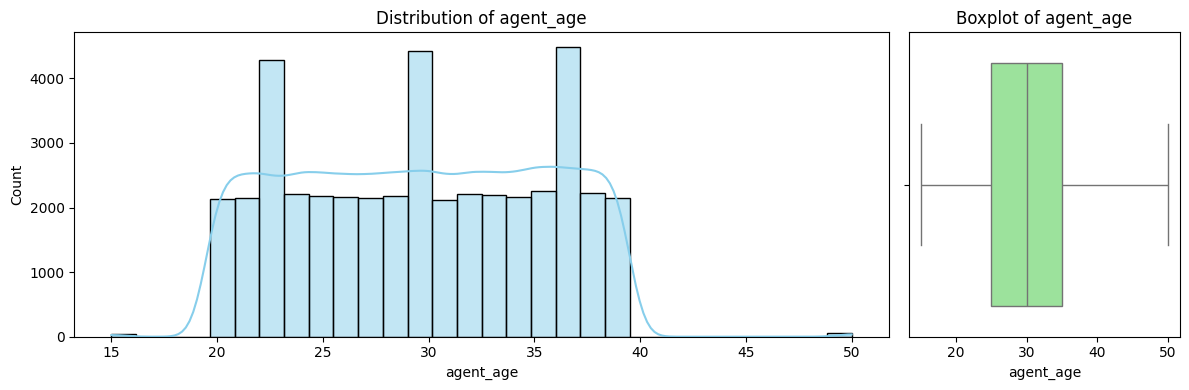

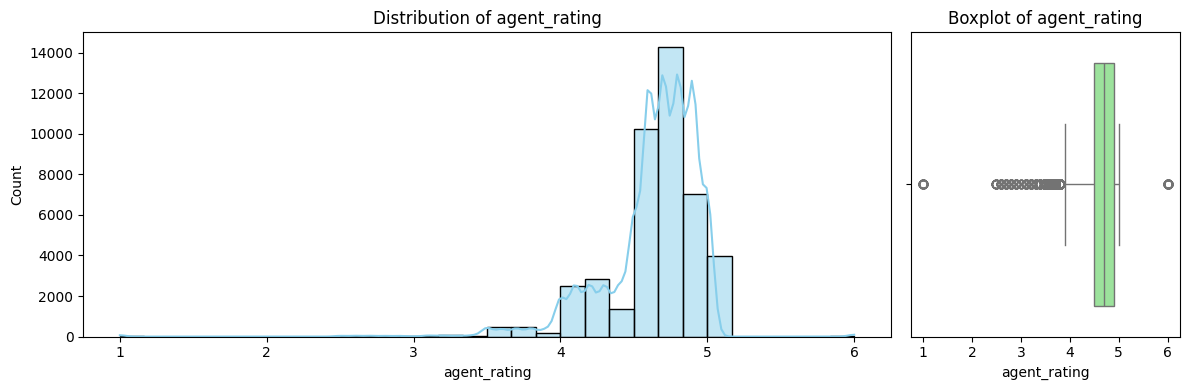

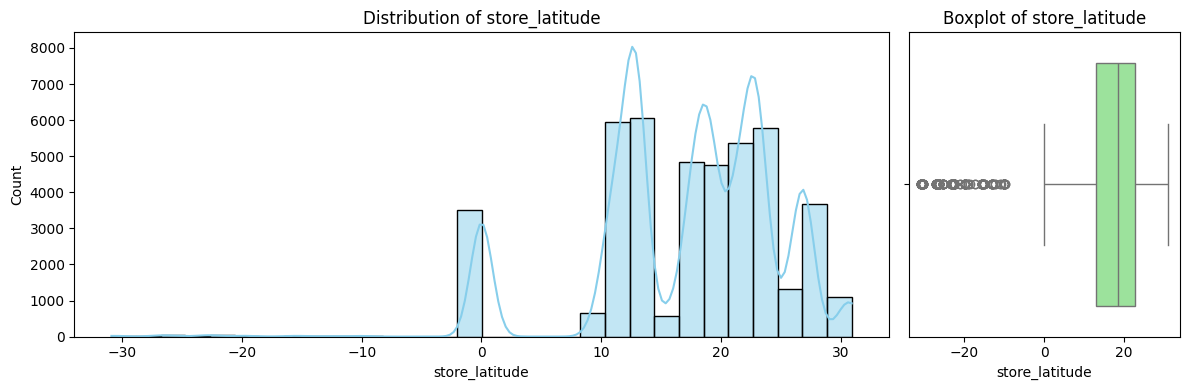

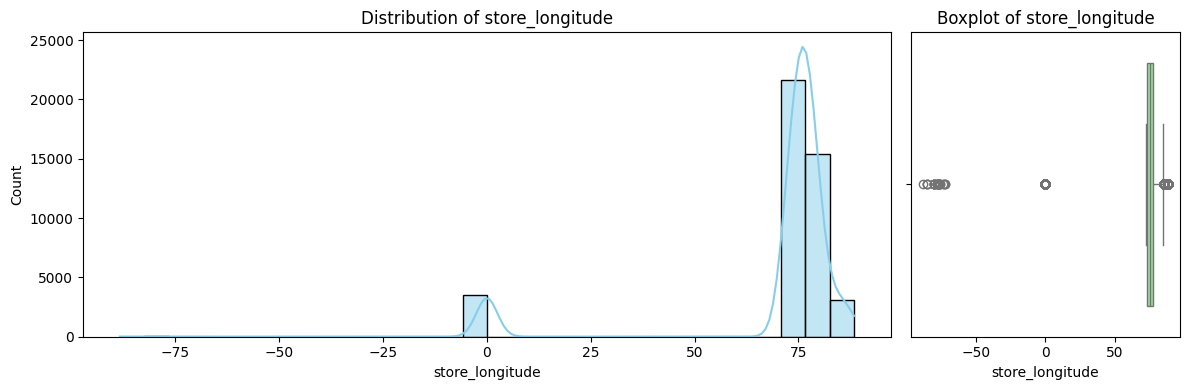

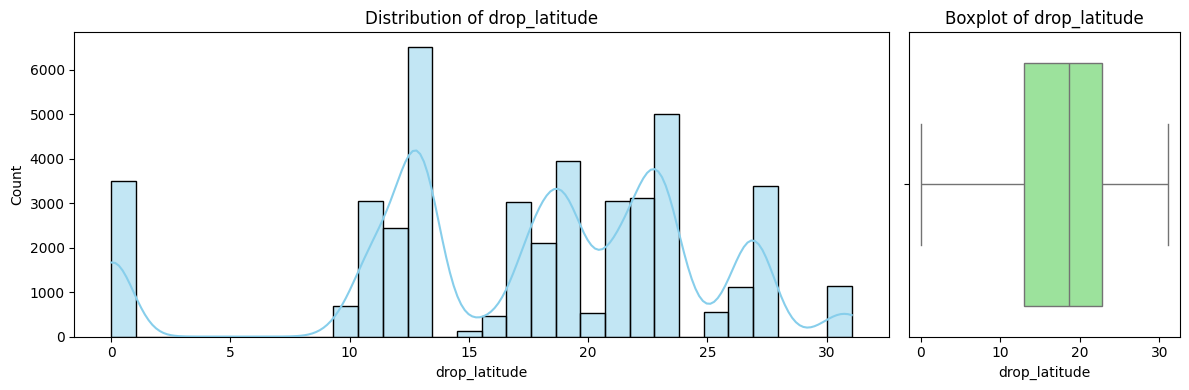

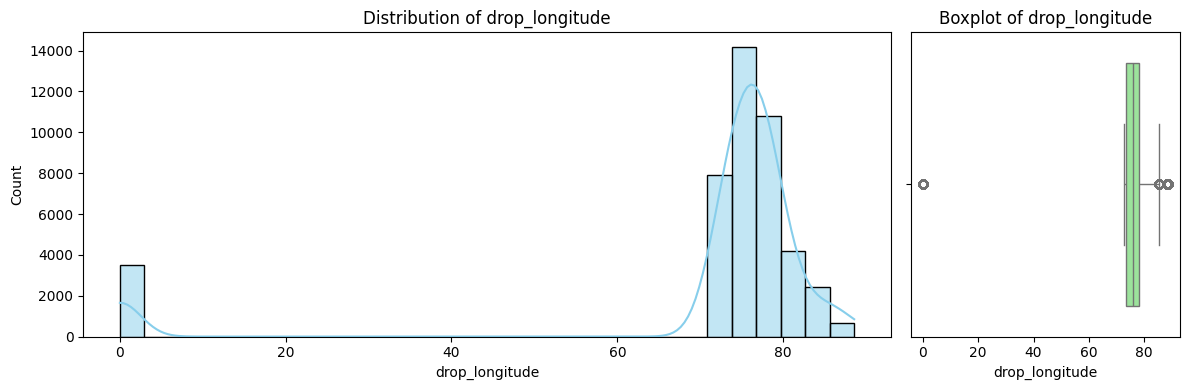

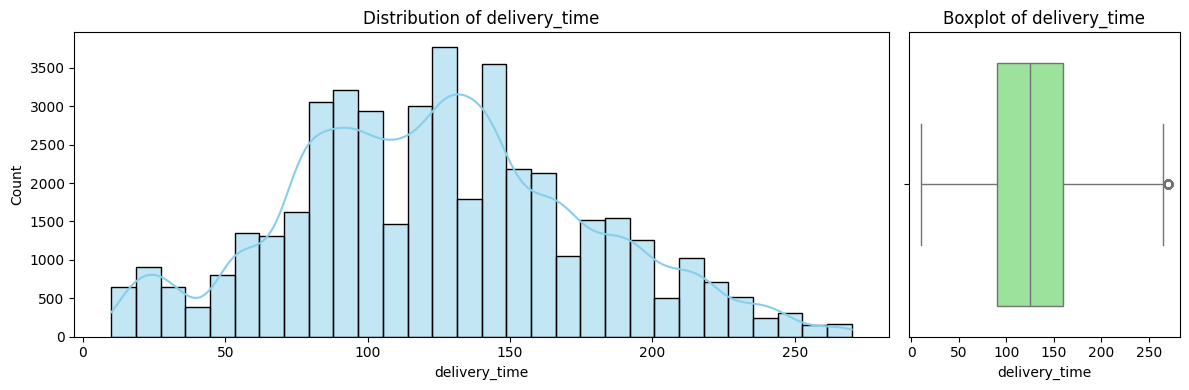

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [3, 1]})

    # Histogram with KDE on left
    sns.histplot(df[col], kde=True, bins=30, ax=axs[0], color='skyblue')
    axs[0].set_title(f"Distribution of {col}")

    # Boxplot on right
    sns.boxplot(x=df[col], ax=axs[1], color='lightgreen')
    axs[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

In [25]:
# Value counts for categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
  print_bold(f"\n===== Value Counts for {col} =====")
  print(df[col].value_counts().head(10))


===== Value Counts for order_id =====
order_id
nsyz997960170    1
ialx566343618    1
akqg208421122    1
njpu434582536    1
rjto796129700    1
zguw716275638    1
fxuu788413734    1
njmo150975311    1
jvjc772545076    1
uaeb808891380    1
Name: count, dtype: int64

===== Value Counts for weather =====
weather
Fog           7440
Stormy        7374
Cloudy        7288
Sandstorms    7245
Windy         7223
Sunny         7078
Name: count, dtype: int64

===== Value Counts for traffic =====
traffic
Low        14999
Jam        13725
Medium     10628
High        4296
NaN           91
Name: count, dtype: int64

===== Value Counts for vehicle =====
vehicle
motorcycle     25527
scooter        14639
van             3558
bicycle           15
Name: count, dtype: int64

===== Value Counts for area =====
area
Metropolitian     32698
Urban              9751
Other              1138
Semi-Urban          152
Name: count, dtype: int64

===== Value Counts for category =====
category
Electronics    2849
Books  

In [26]:
df[df['weather'].isna()]

,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category
2286,xige084493792,15,1.0,-26.891191,75.802083,26.981191,75.892083,2022-03-12,NaT,0 days 17:20:00,NaN,NaN,motorcycle,Urban,75,Home
2779,oilg311747812,15,1.0,22.750040,75.902847,22.810040,75.962847,2022-04-03,NaT,0 days 20:30:00,NaN,NaN,scooter,Metropolitian,145,Kitchen
2825,pbox816153129,15,1.0,21.149569,72.772697,21.209569,72.832697,2022-03-21,NaT,0 days 22:10:00,NaN,NaN,bicycle,Metropolitian,100,Clothing
3438,nzsa056960624,50,6.0,-12.970324,-77.645748,13.010324,77.685748,2022-03-13,NaT,0 days 12:30:00,NaN,NaN,van,Urban,125,Cosmetics
4514,eids248121351,50,6.0,-17.451976,-78.385883,17.561976,78.495883,2022-04-04,NaT,0 days 23:20:00,NaN,NaN,bicycle,Metropolitian,135,Jewelry
4958,tznn437423907,50,6.0,-26.910262,-75.783013,27.020262,75.893013,2022-03-18,NaT,0 days 18:50:00,NaN,NaN,scooter,Metropolitian,100,Skincare
5142,dazy306268524,50,6.0,12.914264,77.678400,13.024264,77.788400,2022-04-06,NaT,0 days 20:55:00,NaN,NaN,van,Metropolitian,18,Grocery
5418,jzlx800086920,50,6.0,-27.159795,-78.042990,27.209795,78.092990,2022-02-13,NaT,0 days 18:05:00,NaN,NaN,scooter,Metropolitian,100,Electronics
5659,pjec796867569,15,1.0,13.026286,80.275235,13.056286,80.305235,2022-03-11,NaT,0 days 20:50:00,NaN,NaN,bicycle,Metropolitian,125,Electronics
6132,yiuy815061054,50,6.0,26.911927,75.797282,27.041927,75.927282,2022-04-02,NaT,0 days 22:10:00,NaN,NaN,van,Urban,100,Shoes


#### **Weather and Traffic are missing at the same time in the DataFrame**

In [27]:
df.isna().sum()

,0
order_id,0
agent_age,0
agent_rating,54
store_latitude,0
store_longitude,0
drop_latitude,0
drop_longitude,0
order_date,0
order_time,91
pickup_time,0


In [28]:
df['traffic'].replace('NaN', np.nan, inplace=True)

In [29]:
nan_in_any_column = df[df.isna().any(axis=1)]
nan_in_any_column

,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category
124,uurs547552548,23,NaN,22.569358,88.433452,22.599358,88.463452,2022-02-17,0 days 23:25:00,0 days 23:35:00,Sunny,Low,motorcycle,Metropolitian,75,Snacks
1996,xoaj834389107,32,NaN,0.000000,0.000000,0.050000,0.050000,2022-02-11,0 days 20:50:00,0 days 21:00:00,Sandstorms,Jam,motorcycle,Urban,185,Snacks
2002,lasr795083832,23,NaN,25.454648,81.834502,25.584648,81.964502,2022-02-18,0 days 19:50:00,0 days 19:55:00,Windy,Jam,motorcycle,Metropolitian,150,Outdoors
2018,gjcr517387117,26,NaN,0.000000,0.000000,0.080000,0.080000,2022-02-16,0 days 23:50:00,0 days 23:55:00,Cloudy,Low,scooter,Metropolitian,140,Clothing
2286,xige084493792,15,1.0,-26.891191,75.802083,26.981191,75.892083,2022-03-12,NaT,0 days 17:20:00,NaN,NaN,motorcycle,Urban,75,Home
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41504,ogxf318978500,20,NaN,25.451517,81.832616,25.501517,81.882616,2022-02-13,0 days 22:15:00,0 days 22:30:00,Stormy,Low,scooter,Urban,85,Shoes
42598,llox673359294,15,1.0,0.000000,0.000000,0.070000,0.070000,2022-03-14,NaT,0 days 17:40:00,NaN,NaN,scooter,Metropolitian,170,Jewelry
43027,qhka163034669,20,NaN,22.514585,88.393310,22.594585,88.473310,2022-02-14,0 days 22:20:00,0 days 22:25:00,Fog,Low,scooter,Metropolitian,100,Electronics
43053,ifig993965994,15,1.0,13.086438,80.220672,13.216439,80.350672,2022-03-18,NaT,0 days 18:00:00,NaN,NaN,van,Urban,130,Jewelry


In [30]:
df[df['traffic']=='NaN']

,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category


In [31]:
df[df['category']=="Sports"]

,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,0 days 08:30:00,0 days 08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
34,agoo012263585,32,4.6,18.563934,73.915367,18.693935,74.045367,2022-04-02,0 days 22:35:00,0 days 22:45:00,Cloudy,Low,scooter,Metropolitian,150,Sports
58,etss702593505,36,4.7,0.000000,0.000000,0.060000,0.060000,2022-03-13,0 days 20:15:00,0 days 20:20:00,Cloudy,Jam,motorcycle,Metropolitian,150,Sports
69,tsec016509855,22,4.7,21.157735,72.768778,21.197735,72.808778,2022-03-17,0 days 12:10:00,0 days 12:15:00,Sunny,High,scooter,Urban,90,Sports
74,bhdi726355812,20,4.5,0.000000,0.000000,0.050000,0.050000,2022-02-11,0 days 21:10:00,0 days 21:25:00,Fog,Jam,motorcycle,Metropolitian,135,Sports
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43608,cwhd429481472,27,4.7,21.157729,72.768726,21.207729,72.818726,2022-03-21,0 days 19:45:00,0 days 19:50:00,Windy,Jam,motorcycle,Metropolitian,165,Sports
43638,lyou528718992,36,4.2,12.323225,76.630028,12.433225,76.740028,2022-03-06,0 days 21:25:00,0 days 21:30:00,Stormy,Jam,motorcycle,Metropolitian,245,Sports
43672,cgjs691919929,24,4.9,17.440827,78.393391,17.520827,78.473391,2022-03-08,0 days 20:20:00,0 days 20:30:00,Cloudy,Jam,scooter,Metropolitian,220,Sports
43729,llbw528617620,36,4.8,12.310972,76.659264,12.440972,76.789264,2022-03-18,0 days 21:10:00,0 days 21:20:00,Sunny,Jam,van,Urban,145,Sports


In [32]:
for col in df.select_dtypes(exclude =['int32', 'int64', 'float64', 'datetime64[ns]']):
  print(df[col].value_counts().head(10))

order_id
nsyz997960170    1
ialx566343618    1
akqg208421122    1
njpu434582536    1
rjto796129700    1
zguw716275638    1
fxuu788413734    1
njmo150975311    1
jvjc772545076    1
uaeb808891380    1
Name: count, dtype: int64
order_time
0 days 21:55:00    460
0 days 17:55:00    453
0 days 20:00:00    446
0 days 22:20:00    446
0 days 21:35:00    445
0 days 19:50:00    444
0 days 21:20:00    437
0 days 21:15:00    437
0 days 22:45:00    435
0 days 18:10:00    435
Name: count, dtype: int64
pickup_time
0 days 21:30:00    481
0 days 22:50:00    450
0 days 21:45:00    445
0 days 22:25:00    441
0 days 17:55:00    440
0 days 18:05:00    439
0 days 23:50:00    438
0 days 18:40:00    437
0 days 22:40:00    437
0 days 23:35:00    434
Name: count, dtype: int64
weather
Fog           7440
Stormy        7374
Cloudy        7288
Sandstorms    7245
Windy         7223
Sunny         7078
Name: count, dtype: int64
traffic
Low        14999
Jam        13725
Medium     10628
High        4296
NaN           91

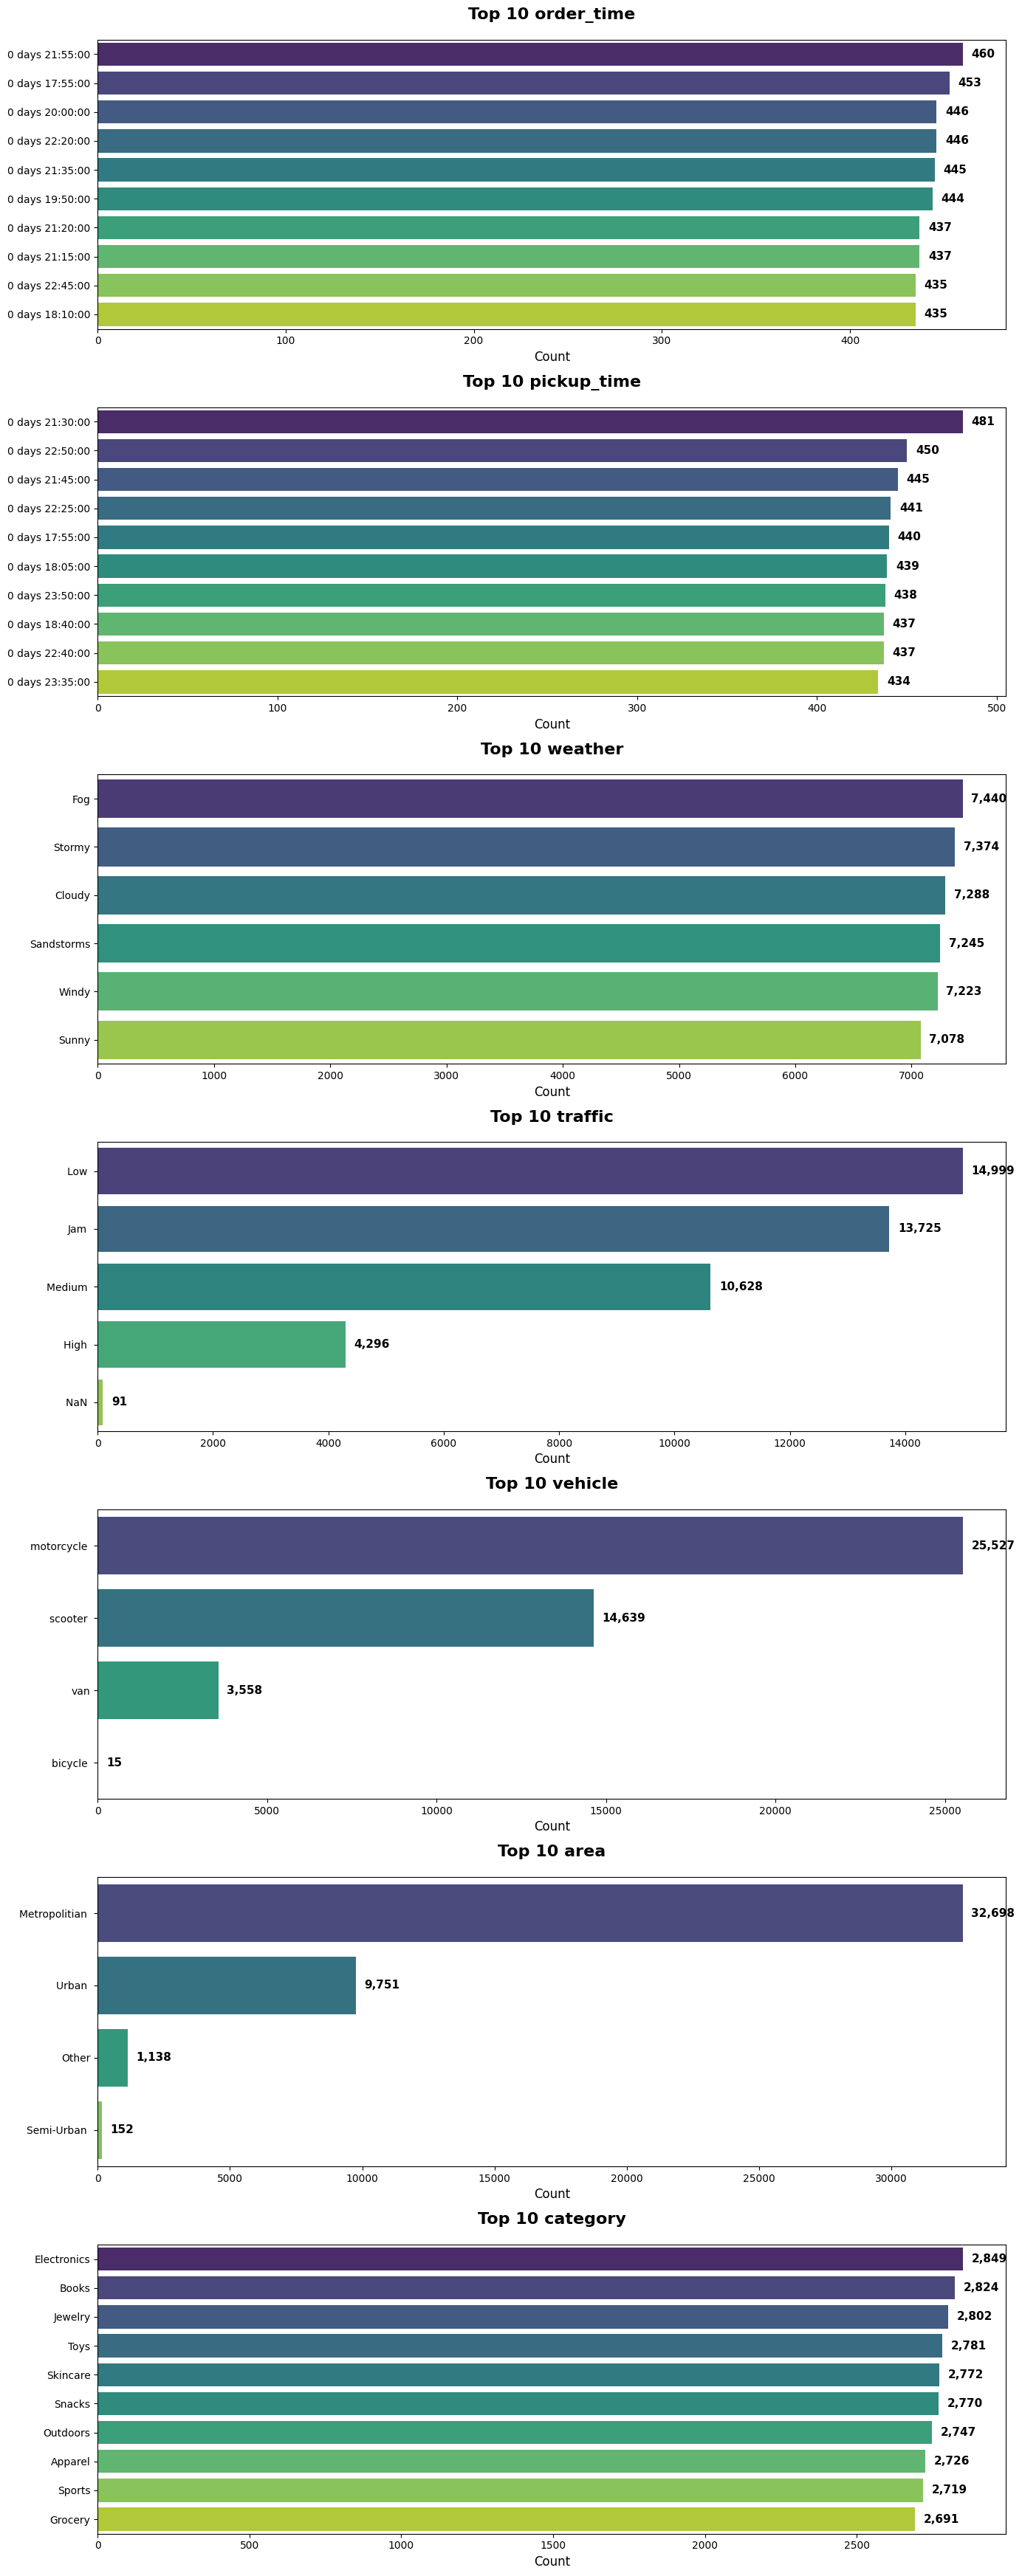

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = df.drop(['order_id'],axis=1).select_dtypes(exclude=['int32', 'int64', 'float64', 'datetime64[ns]']).columns

# Set up the plot grid
n_cols = len(categorical_cols)
fig, axes = plt.subplots(n_cols, 1, figsize=(14, 5 * n_cols))

if n_cols == 1:
    axes = [axes]

for idx, col in enumerate(categorical_cols):
    # Get top 10 and create DataFrame for seaborn
    top_10 = df[col].value_counts().head(10).reset_index()
    top_10.columns = ['value', 'count']

    # Create seaborn bar plot
    sns.barplot(data=top_10, x='count', y='value', ax=axes[idx],
                palette='viridis', hue='value', legend=False)

    axes[idx].set_title(f'Top 10 {col}', fontsize=16, fontweight='bold', pad=20)
    axes[idx].set_xlabel('Count', fontsize=12)
    axes[idx].set_ylabel('')

    # Add value annotations
    for i, v in enumerate(top_10['count']):
        axes[idx].text(v + 0.01 * max(top_10['count']), i, f'{v:,}',
                      va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
cat_cols = df.select_dtypes( exclude = ['int32', 'int64', 'float64', 'datetime64[ns]'] )
cat_cols.drop(['order_id'],axis=1,inplace=True)
#Check Unique Values for each variable.
cat_cols.apply(lambda x: x.value_counts()).T.stack()

order_time  0 days 00:00:00     429.0
            0 days 08:10:00     167.0
            0 days 08:15:00     176.0
            0 days 08:20:00     182.0
            0 days 08:25:00     177.0
                                ...  
category    Shoes              2666.0
            Skincare           2772.0
            Snacks             2770.0
            Sports             2719.0
            Toys               2781.0
Length: 404, dtype: float64

In [35]:
# df['order_time'] = pd.to_datetime(df['order_time'],format='%H:%M:%S',errors='coerce')
# order_time
# 1900-01-01 21:55:00    460

In [36]:
#  df['order_datetime'] = pd.to_datetime(df['order_date'] + ' ' + df['order_time'], format='%Y-%m-%d %H:%M:%S')

In [37]:
for col in df.select_dtypes(exclude =['int32', 'int64', 'float64']):#, 'datetime64[ns]'
  print(df[col].value_counts().head(10))

order_id
nsyz997960170    1
ialx566343618    1
akqg208421122    1
njpu434582536    1
rjto796129700    1
zguw716275638    1
fxuu788413734    1
njmo150975311    1
jvjc772545076    1
uaeb808891380    1
Name: count, dtype: int64
order_date
2022-03-15    1141
2022-04-03    1133
2022-03-13    1123
2022-03-26    1119
2022-03-03    1119
2022-03-09    1117
2022-03-05    1112
2022-03-24    1112
2022-03-21    1107
2022-04-05    1106
Name: count, dtype: int64
order_time
0 days 21:55:00    460
0 days 17:55:00    453
0 days 20:00:00    446
0 days 22:20:00    446
0 days 21:35:00    445
0 days 19:50:00    444
0 days 21:20:00    437
0 days 21:15:00    437
0 days 22:45:00    435
0 days 18:10:00    435
Name: count, dtype: int64
pickup_time
0 days 21:30:00    481
0 days 22:50:00    450
0 days 21:45:00    445
0 days 22:25:00    441
0 days 17:55:00    440
0 days 18:05:00    439
0 days 23:50:00    438
0 days 18:40:00    437
0 days 22:40:00    437
0 days 23:35:00    434
Name: count, dtype: int64
weather
Fog  

In [38]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.drop(['order_id'], errors='ignore')
cat_cols

Index(['weather', 'traffic', 'vehicle', 'area', 'category'], dtype='object')

### Check Unique Values for each variable.

---



In [39]:
#Check Unique Values for each variable.
# cat_cols.apply(lambda x: x.value_counts()).T.stack()

In [40]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.drop(['order_id'], errors='ignore')

# This will create a Series where each value is a Series of value counts for that column
unique_vals = df[cat_cols].apply(lambda x: x.value_counts()).T.stack()
unique_vals

weather   Cloudy             7288.0
          Fog                7440.0
          Sandstorms         7245.0
          Stormy             7374.0
          Sunny              7078.0
          Windy              7223.0
traffic   High               4296.0
          Jam               13725.0
          Low               14999.0
          Medium            10628.0
          NaN                  91.0
vehicle   bicycle              15.0
          motorcycle        25527.0
          scooter           14639.0
          van                3558.0
area      Metropolitian     32698.0
          Other              1138.0
          Semi-Urban          152.0
          Urban              9751.0
category  Apparel            2726.0
          Books              2824.0
          Clothing           2667.0
          Cosmetics          2677.0
          Electronics        2849.0
          Grocery            2691.0
          Home               2685.0
          Jewelry            2802.0
          Kitchen            2673.0
          Outdoors           2747.0
          Pet Supplies       2690.0
          Shoes              2666.0
          Skincare           2772.0
          Snacks             2770.0
          Sports             2719.0
          Toys               2781.0
dtype: float64

In [41]:
df = df.dropna()

In [42]:
df.drop(['order_id'],axis=1,inplace=True)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43594 entries, 0 to 43738
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype          
---  ------           --------------  -----          
 0   agent_age        43594 non-null  int64          
 1   agent_rating     43594 non-null  float64        
 2   store_latitude   43594 non-null  float64        
 3   store_longitude  43594 non-null  float64        
 4   drop_latitude    43594 non-null  float64        
 5   drop_longitude   43594 non-null  float64        
 6   order_date       43594 non-null  datetime64[ns] 
 7   order_time       43594 non-null  timedelta64[ns]
 8   pickup_time      43594 non-null  timedelta64[ns]
 9   weather          43594 non-null  object         
 10  traffic          43594 non-null  object         
 11  vehicle          43594 non-null  object         
 12  area             43594 non-null  object         
 13  delivery_time    43594 non-null  int64          
 14  category         43594 non-

## 3. ***Data Wrangling***

### Data Wrangling Code

In [44]:
# Use this for most cases
# import pandas as pd

# Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract the three main components
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day


print(f"✅ Extracted year, month, day from {len(df)} orders")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")

✅ Extracted year, month, day from 43594 orders
Date range: 2022-02-11 to 2022-04-06


In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43594 entries, 36718 to 28480
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype          
---  ------           --------------  -----          
 0   agent_age        43594 non-null  int64          
 1   agent_rating     43594 non-null  float64        
 2   store_latitude   43594 non-null  float64        
 3   store_longitude  43594 non-null  float64        
 4   drop_latitude    43594 non-null  float64        
 5   drop_longitude   43594 non-null  float64        
 6   order_date       43594 non-null  datetime64[ns] 
 7   order_time       43594 non-null  timedelta64[ns]
 8   pickup_time      43594 non-null  timedelta64[ns]
 9   weather          43594 non-null  object         
 10  traffic          43594 non-null  object         
 11  vehicle          43594 non-null  object         
 12  area             43594 non-null  object         
 13  delivery_time    43594 non-null  int64          
 14  category         43594 

In [190]:
# Calculate distance between store and drop locations (Haversine distance)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c



In [189]:
df['distance_km'] = haversine_distance(
    df['store_latitude'], df['store_longitude'],
    df['drop_latitude'], df['drop_longitude']
)

In [141]:
df['time_to_deliver'] = (df['pickup_time'] - df['order_time'])

In [175]:
# Calculate the timedelta
df['time_to_pickup'] = df['pickup_time'] - df['order_time']

# Extract the duration in hours
df['pickup_hours'] = df['time_to_pickup'].dt.total_seconds() / 3600

In [176]:
df['pickup_hours']

,pickup_hours
36718,0.083333
31233,0.083333
31237,0.166667
18091,0.083333
18061,0.083333
...,...
41023,0.250000
21368,0.250000
28977,0.250000
21427,0.083333


In [45]:
df['day_name'] = df['order_date'].dt.strftime("%A")


In [46]:
df['day_name']

,day_name
0,Saturday
1,Friday
2,Saturday
3,Tuesday
4,Saturday
...,...
43734,Thursday
43735,Wednesday
43736,Friday
43737,Monday


In [47]:
df['order_day']

,order_day
0,19
1,25
2,19
3,5
4,26
...,...
43734,24
43735,16
43736,11
43737,7


## ***4. Data Visualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### **Chart - 1**

In [48]:
print(f"✅ Extracted year, month, day from {len(df)} orders")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")

✅ Extracted year, month, day from 43594 orders
Date range: 2022-02-11 to 2022-04-06


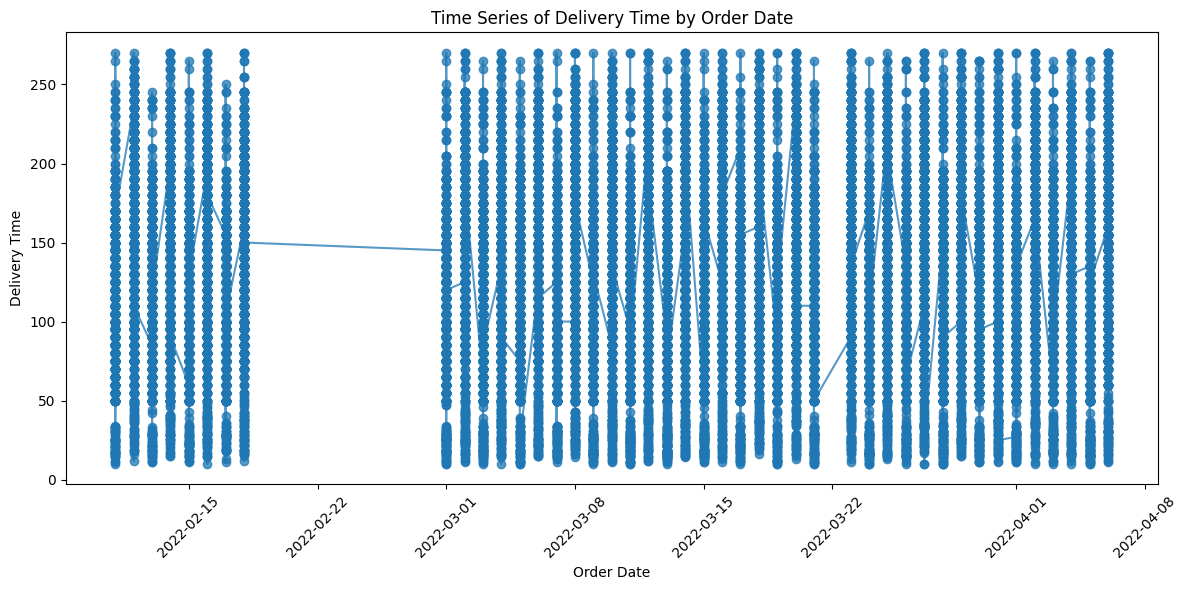

In [49]:
#Convert order_date to datetime if not already
df['order_date'] = pd.to_datetime(df['order_date'])

#Sort by order_date (recommended for time series)
df = df.sort_values('order_date')

# Plot time series
plt.figure(figsize=(12,6))
plt.plot(df['order_date'], df['delivery_time'], marker='o', linestyle='-', alpha=0.75)
plt.xlabel('Order Date')
plt.ylabel('Delivery Time')
plt.title('Time Series of Delivery Time by Order Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
x = df['order_date']
y = df['delivery_time']

In [51]:
# df.plot(x=x, y=y, kind='line', marker='o')
# plt.title('DataFrame Line Plot')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.show()


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulate the order_date column as described (43739 entries, datetime64[ns])
n_rows = 43739
start_date = df['order_date'].min().date()
end_date = df['order_date'].max().date()

# Generate a series of random datetimes
# Create a range of possible timestamps within the period (hourly frequency)
# # time_range = pd.date_range(start=start_date, end=end_date, freq='H')
# # # Sample 43739 datetimes from this range with replacement
# # dates = np.random.choice(time_range, size=n_rows)
# # # Convert to a DataFrame
# df = pd.DataFrame({'order_date': dates})
# df['order_date'] = pd.to_datetime(df['order_date']) # Ensure correct dtype

# Prepare data for plotting: Count of orders per day
# Extract just the date part for aggregation
df['order_day'] = df['order_date'].dt.date
# Calculate daily counts
daily_counts = df.groupby('order_day').size().reset_index(name='order_count')
# Convert 'order_day' back to datetime for proper plotting
daily_counts['order_day'] = pd.to_datetime(daily_counts['order_day'])
daily_counts = daily_counts.sort_values('order_day')


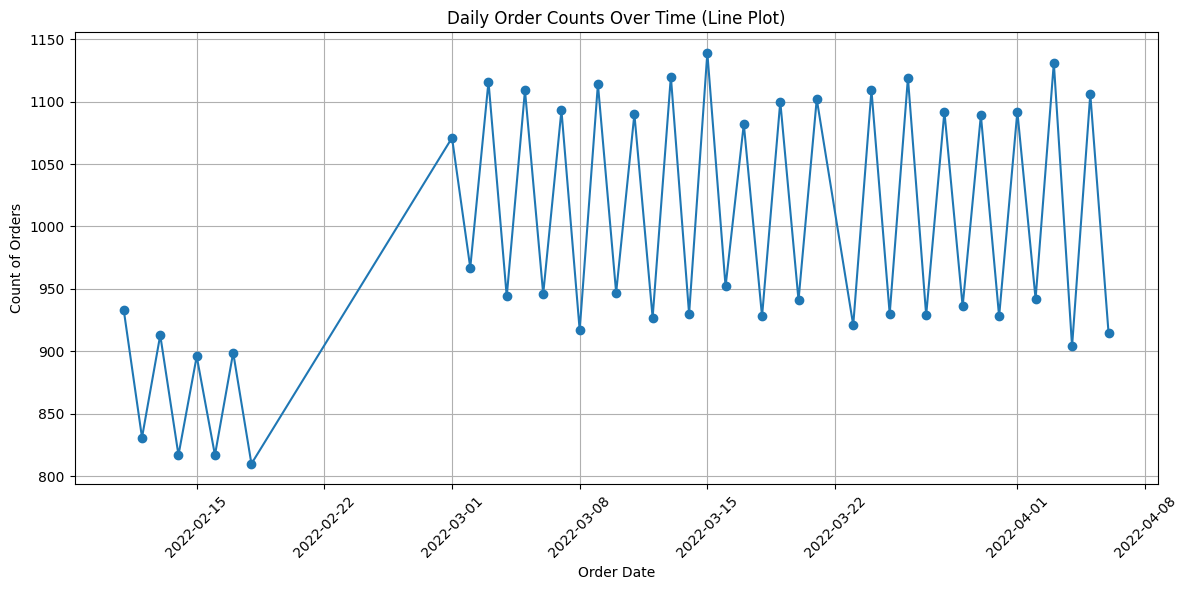

In [53]:
# 1. Line plot of order_date and count
plt.figure(figsize=(12, 6))
plt.plot(daily_counts['order_day'], daily_counts['order_count'], marker='o', linestyle='-')
plt.title('Daily Order Counts Over Time (Line Plot)')
plt.xlabel('Order Date')
plt.ylabel('Count of Orders')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()


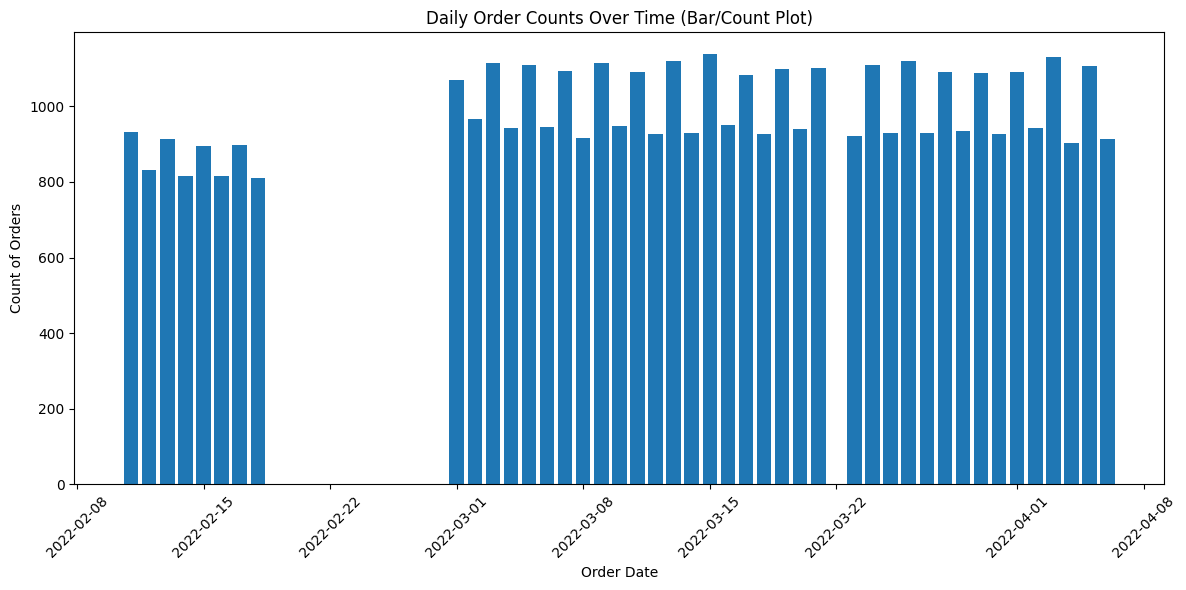

In [54]:
# 2. Count plot of order_date (represented as a bar chart of daily counts)
plt.figure(figsize=(12, 6))
plt.bar(daily_counts['order_day'], daily_counts['order_count'], width=0.8)
plt.title('Daily Order Counts Over Time (Bar/Count Plot)')
plt.xlabel('Order Date')
plt.ylabel('Count of Orders')
plt.xticks(rotation=45)
plt.tight_layout()

In [55]:
df[(df['order_date'] > '2022-02-18') & (df['order_date'] < '2022-03-01')]

,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category,order_year,order_month,order_day,day_name


## The above bar graph shows a period of inactivity between '2022-02-18' and '2022-03-01'. This requires further discussions in client meetings before reaching any conclusion.

1. Initial Growth Phase (Mid-Feb to Early March)
The plot shows a significant upward trend in daily orders during the initial phase. Order counts start around 950 on the first recorded day and drop to a low point near 825.

2. There's a rapid recovery and sharp increase, climbing from the low point to a peak around 1080 by the beginning of March. This suggests a major business growth event or a seasonal shift occurred around late February 2022.

3. Stable, Cyclical Pattern (March Onward)
After the initial sharp increase, the daily order count stabilizes into a clear, highly predictable, cyclical pattern.

The cycle repeats almost perfectly every seven days, which is a strong indicator of a weekly pattern.
  

*   Peak Days: Orders consistently peak between 1100 and 1140.
*   Trough Days: Orders consistently drop to a trough between 925 and 950.


The difference between the peak and trough is substantial (around 150−200 orders), highlighting that the day of the week is a critical factor in order volume. The peak likely corresponds to a high-demand day (e.g., Saturday or Sunday), and the trough to a low-demand day (e.g., a weekday like Tuesday or Wednesday).

## **Conclusion:**
Despite the significant weekly fluctuations, the overall average order count remains relatively constant after the jump in early March. The weekly peaks and troughs do not show a strong sustained increase or decrease over the March-April period, suggesting the business has reached a stable level of operation with established weekly habits among its customer base.

### **Chart - 2**

In [56]:
pivot_table = df.pivot_table(
    values='delivery_time',
    index='order_date',
    columns='traffic',
    aggfunc='mean'
)

In [57]:
mean_delivery_time = df.groupby('traffic')['delivery_time'].mean().sort_values(ascending=False).reset_index(name='mean_delivery_time')


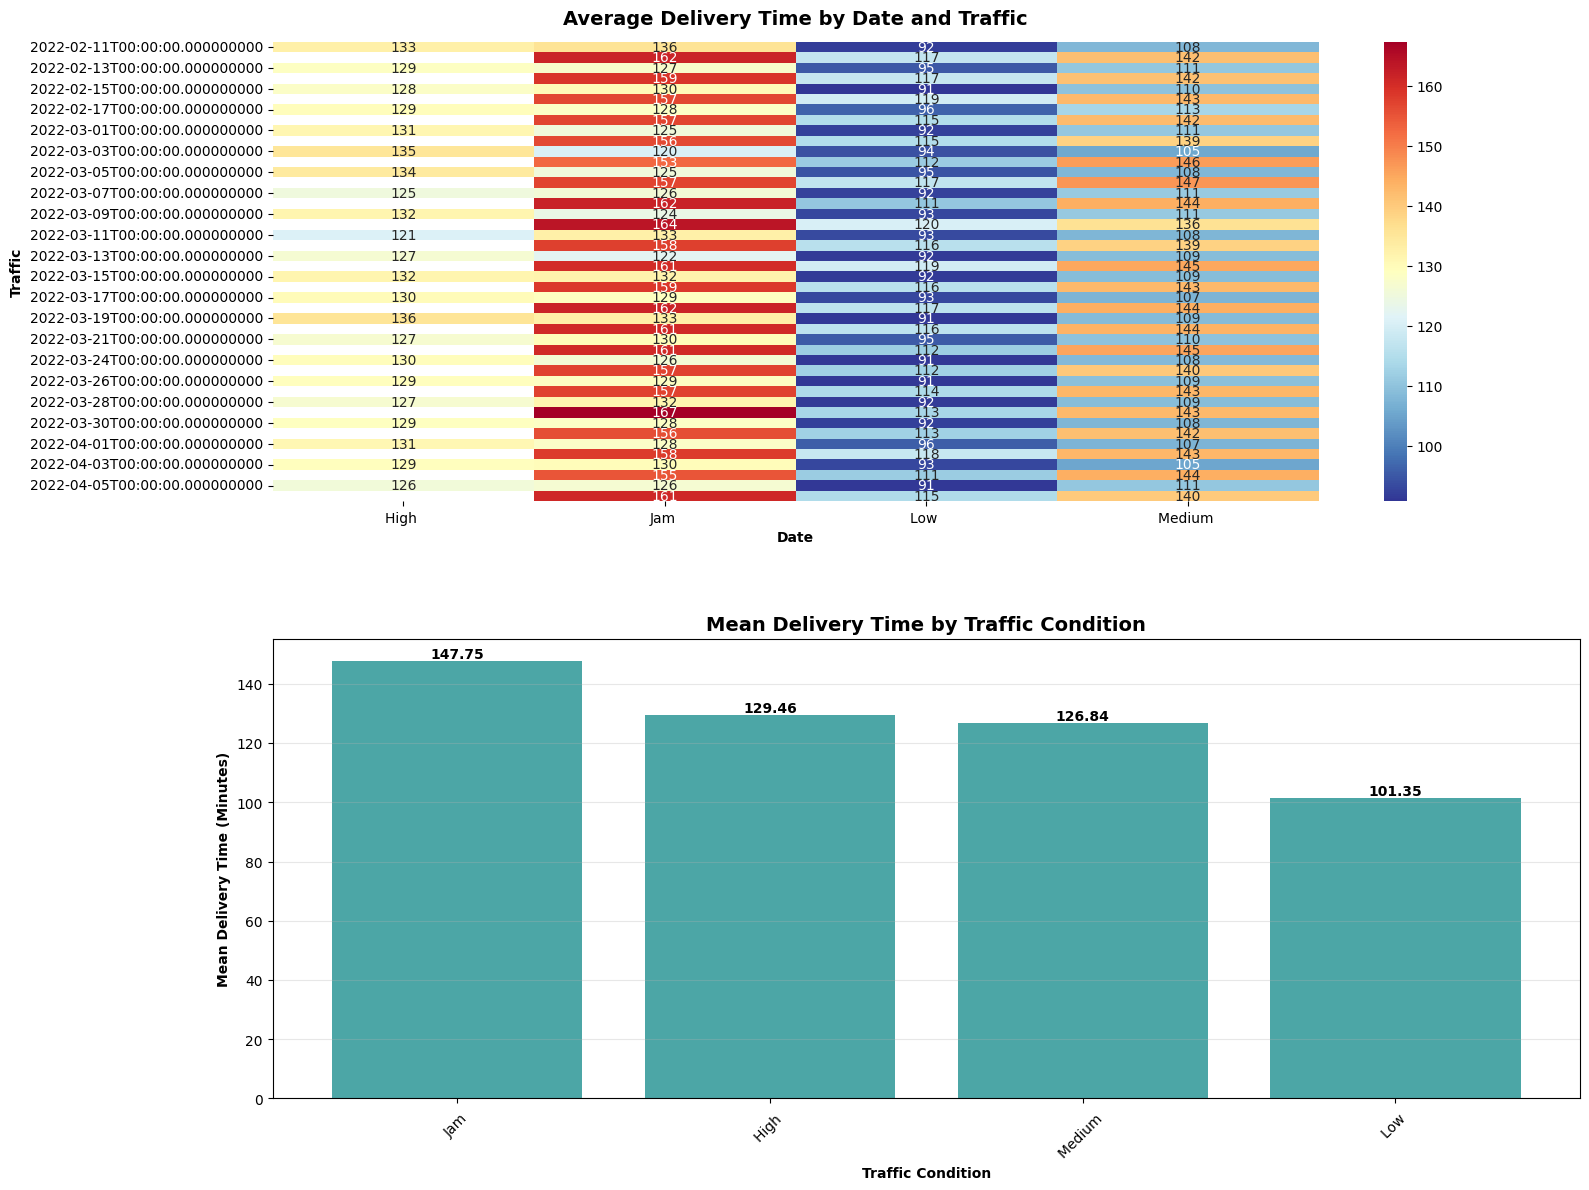

In [58]:
# Create a 2-row, 1-column subplot with better proportions
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# =============================================================================
# 1. HEATMAP - Average Delivery Time by Date and Traffic
# =============================================================================
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='RdYlBu_r', ax=axes[0])
axes[0].set_title('Average Delivery Time by Date and Traffic', fontweight='bold', fontsize=14, y=1.02)
axes[0].set_xlabel('Date', fontweight='bold')
axes[0].set_ylabel('Traffic', fontweight='bold')

# =============================================================================
# 2. BAR PLOT - Mean Delivery Time by Traffic
# =============================================================================
bars = axes[1].bar(mean_delivery_time['traffic'], mean_delivery_time['mean_delivery_time'], color='teal', alpha=0.7)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontweight='bold')

axes[1].set_title('Mean Delivery Time by Traffic Condition', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Traffic Condition', fontweight='bold')
axes[1].set_ylabel('Mean Delivery Time (Minutes)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)  # Adjust space between subplots
plt.show()

Mean Delivery Times by Traffic:
| traffic   |   mean_delivery_time |
|:----------|---------------------:|
| Jam       |               147.75 |
| High      |               129.46 |
| Medium    |               126.84 |
| Low       |               101.35 |


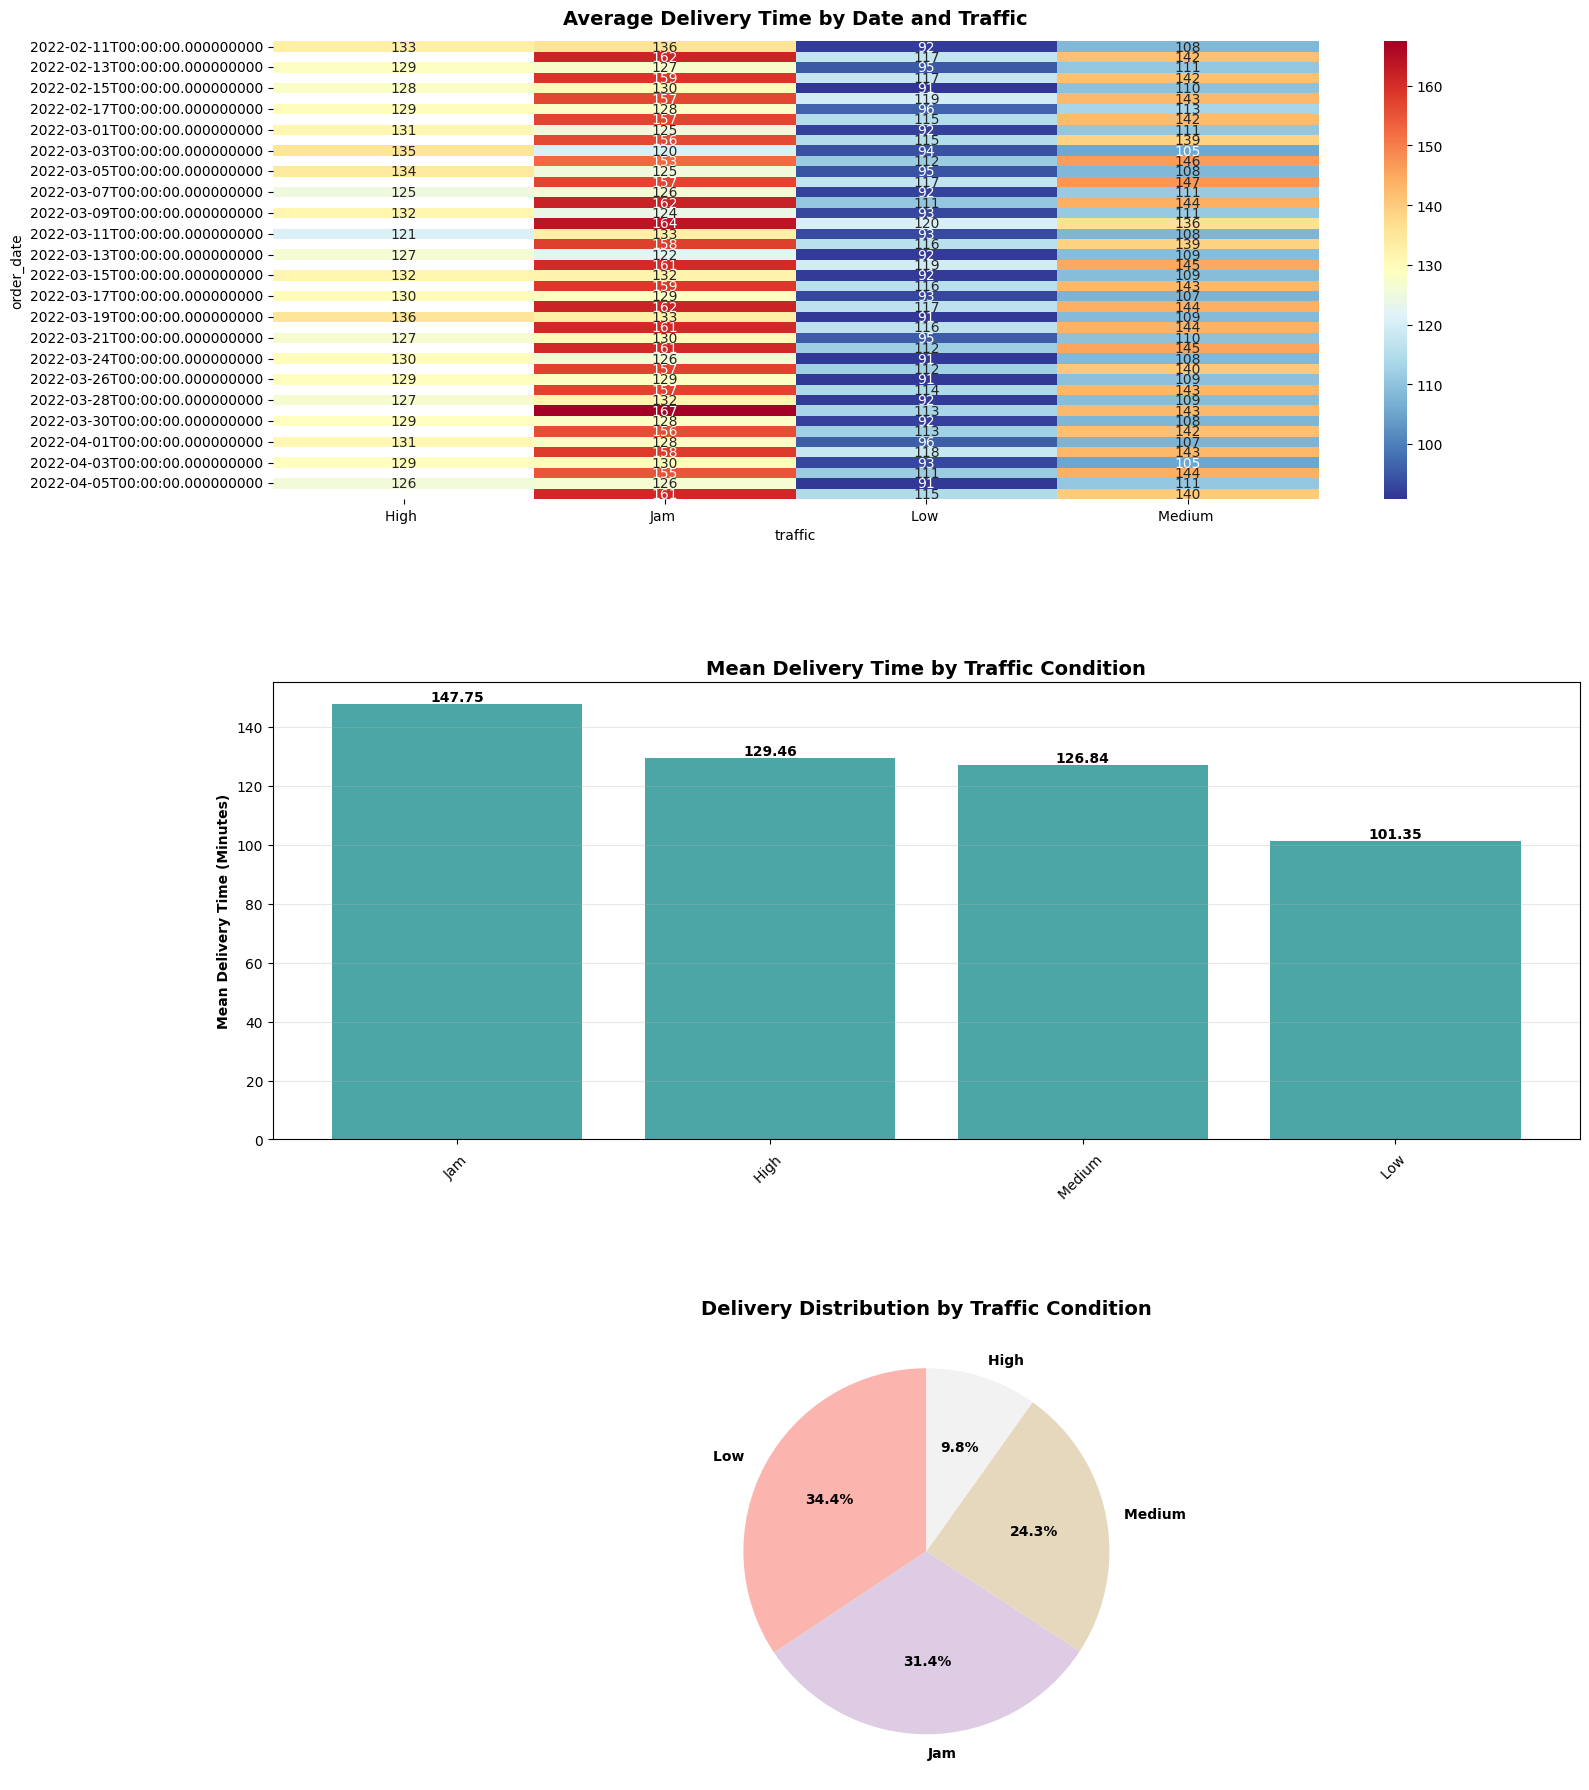

In [59]:
# Create a 3-row, 1-column subplot layout
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# =============================================================================
# 1. HEATMAP - Top
# =============================================================================
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='RdYlBu_r', ax=axes[0])
axes[0].set_title('Average Delivery Time by Date and Traffic', fontweight='bold', fontsize=14, y=1.02)

# =============================================================================
# 2. BAR PLOT - Middle
# =============================================================================
bars = axes[1].bar(mean_delivery_time['traffic'], mean_delivery_time['mean_delivery_time'],
                  color='teal', alpha=0.7)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontweight='bold')

axes[1].set_title('Mean Delivery Time by Traffic Condition', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Mean Delivery Time (Minutes)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# =============================================================================
# 3. PIE CHART - Bottom
# =============================================================================
# Calculate delivery counts for pie chart
delivery_counts = df['traffic'].value_counts()
colors = plt.cm.Pastel1(np.linspace(0, 1, len(delivery_counts)))
wedges, texts, autotexts = axes[2].pie(delivery_counts.values,
                                      labels=delivery_counts.index,
                                      autopct='%1.1f%%',
                                      colors=colors,
                                      startangle=90)

# Enhance pie chart text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

for text in texts:
    text.set_fontweight('bold')

axes[2].set_title('Delivery Distribution by Traffic Condition', fontweight='bold', fontsize=14)




# Group by 'category' and calculate the mean of 'delivery_time'.
# Sort the results for a clean visualization.
mean_delivery_time = df.groupby('traffic')['delivery_time'].mean().sort_values(ascending=False).reset_index(name='mean_delivery_time')

# Print the aggregated data
print("Mean Delivery Times by Traffic:")
print(mean_delivery_time.to_markdown(index=False, floatfmt=".2f"))


# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

In [60]:
traffic_data = df['traffic'].value_counts().reset_index()
traffic_data.set_index('traffic',inplace=True)
traffic_data

,count
traffic,
Low,14976
Jam,13710
Medium,10614
High,4294


**Mean Delivery Time by Traffic Condition**

The bar plot illustrates a clear positive correlation between traffic intensity and the mean delivery time, as expected:

  * Jam Traffic resulted in the longest mean delivery time at 147.75 minutes.

  * High Traffic followed with a mean time of 129.46 minutes.

  * Medium Traffic deliveries averaged 126.84 minutes.

  * Low Traffic had the shortest mean delivery time at 101.35 minutes.

The difference between the shortest (Low Traffic) and longest (Jam Traffic) mean delivery time is substantial, representing a delay of over 46 minutes.

**Delivery Distribution by Traffic Condition** The pie chart breaks down the percentage of all deliveries that occurred under each traffic condition:

The majority of deliveries (nearly two-thirds) occurred under Low and Medium traffic conditions.

  * Low Traffic accounted for the largest share at 34.4%.

  * Medium Traffic accounted for 24.3% of all deliveries.

The remaining deliveries took place under more congested conditions:

  * Jam Traffic represented 31.4% of deliveries.

  * High Traffic was the least frequent condition, accounting for 9.8% of deliveries.



**Business Impact:**

In summary, while Jam Traffic is the most time-consuming condition, a significant volume of deliveries (over 41%) is still conducted in High or Jam traffic, highlighting a major area for potential optimization to reduce overall mean delivery times.












Tools



### **Chart - 3**

In [61]:
list(traffic_data['count'])

[14976, 13710, 10614, 4294]

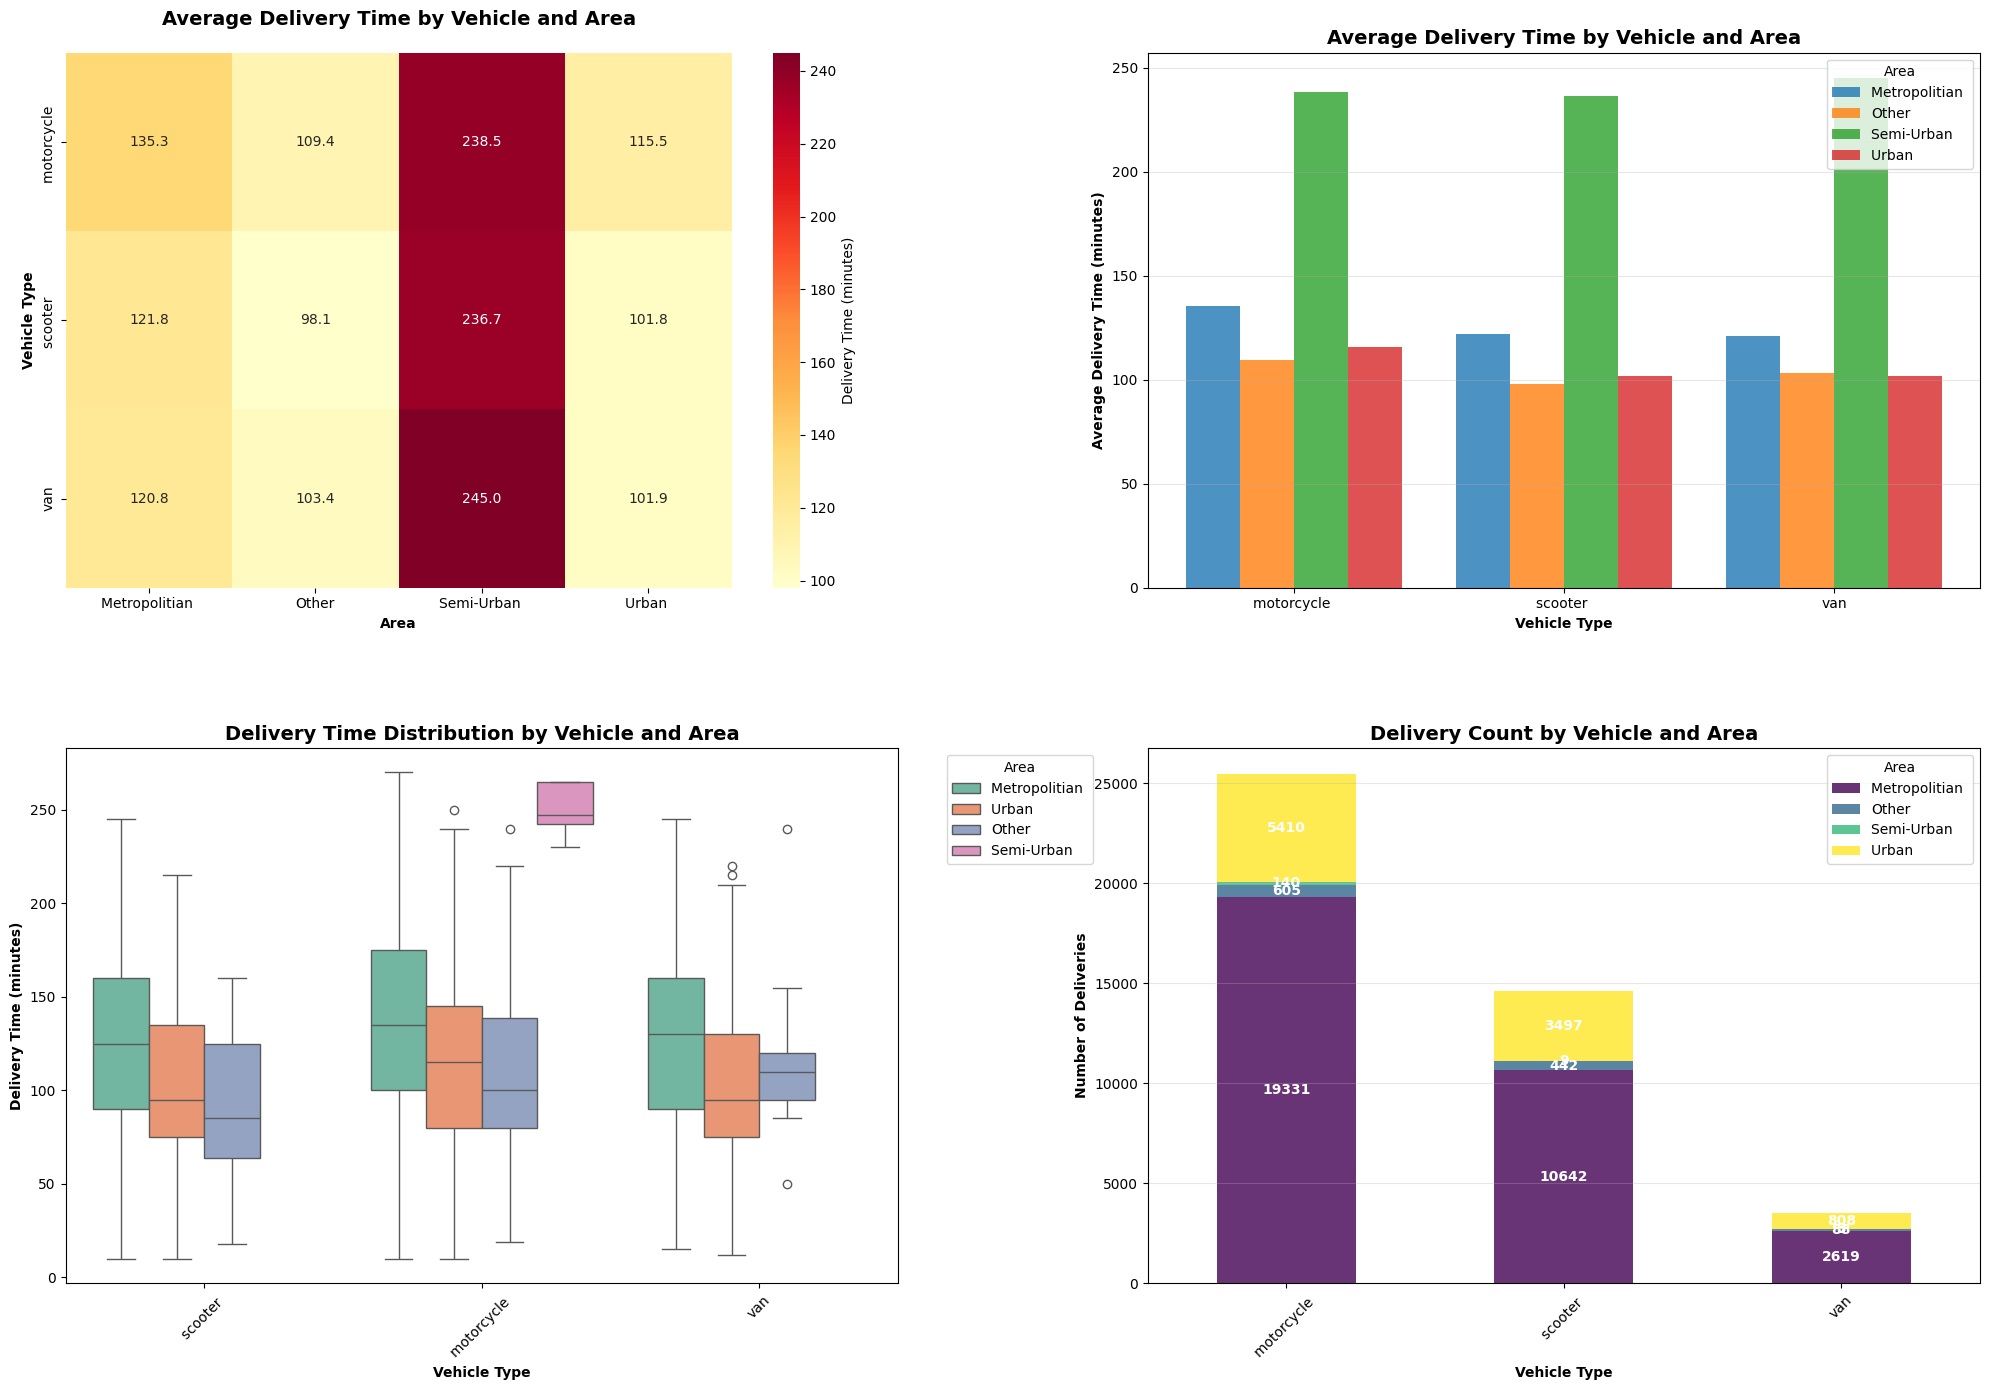

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Create a 2x2 subplot for vehicle, area and delivery time analysis
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# =============================================================================
# 1.1 Heatmap: Average Delivery Time by Vehicle and Area
# =============================================================================
pivot_vehicle_area = df.pivot_table(
    values='delivery_time',
    index='vehicle',
    columns='area',
    aggfunc='mean'
)

sns.heatmap(pivot_vehicle_area, annot=True, fmt=".1f", cmap='YlOrRd',
            ax=axes[0, 0], cbar_kws={'label': 'Delivery Time (minutes)'})
axes[0, 0].set_title('Average Delivery Time by Vehicle and Area',
                     fontweight='bold', fontsize=14, pad=20)
axes[0, 0].set_xlabel('Area', fontweight='bold')
axes[0, 0].set_ylabel('Vehicle Type', fontweight='bold')

# =============================================================================
# 1.2 Grouped Bar Chart: Delivery Time by Vehicle and Area
# =============================================================================
# Prepare data for grouped bar chart
vehicle_area_data = df.groupby(['vehicle', 'area'])['delivery_time'].mean().reset_index()

# Create grouped bar chart
x = np.arange(len(vehicle_area_data['vehicle'].unique()))
width = 0.2
areas = vehicle_area_data['area'].unique()

for i, area in enumerate(areas):
    area_data = vehicle_area_data[vehicle_area_data['area'] == area]
    values = [area_data[area_data['vehicle'] == vehicle]['delivery_time'].values[0]
              if vehicle in area_data['vehicle'].values else 0
              for vehicle in vehicle_area_data['vehicle'].unique()]

    axes[0, 1].bar(x + i*width, values, width, label=area, alpha=0.8)

axes[0, 1].set_xlabel('Vehicle Type', fontweight='bold')
axes[0, 1].set_ylabel('Average Delivery Time (minutes)', fontweight='bold')
axes[0, 1].set_title('Average Delivery Time by Vehicle and Area',
                     fontweight='bold', fontsize=14)
axes[0, 1].set_xticks(x + width*(len(areas)-1)/2)
axes[0, 1].set_xticklabels(vehicle_area_data['vehicle'].unique())
axes[0, 1].legend(title='Area')
axes[0, 1].grid(axis='y', alpha=0.3)

# =============================================================================
# 1.3 Box Plot: Delivery Time Distribution by Vehicle and Area
# =============================================================================
# Create a subset of data for better visualization (if dataset is large)
sample_df = df.sample(min(5000, len(df))) if len(df) > 5000 else df

sns.boxplot(data=sample_df, x='vehicle', y='delivery_time', hue='area',
            ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Delivery Time Distribution by Vehicle and Area',
                     fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Vehicle Type', fontweight='bold')
axes[1, 0].set_ylabel('Delivery Time (minutes)', fontweight='bold')
axes[1, 0].legend(title='Area', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 0].tick_params(axis='x', rotation=45)

# =============================================================================
# 1.4 Stacked Bar Chart: Delivery Count by Vehicle and Area
# =============================================================================
count_data = df.groupby(['vehicle', 'area']).size().unstack(fill_value=0)

count_data.plot(kind='bar', stacked=True, ax=axes[1, 1],
                colormap='viridis', alpha=0.8)
axes[1, 1].set_title('Delivery Count by Vehicle and Area',
                     fontweight='bold', fontsize=14)
axes[1, 1].set_xlabel('Vehicle Type', fontweight='bold')
axes[1, 1].set_ylabel('Number of Deliveries', fontweight='bold')
axes[1, 1].legend(title='Area')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels on stacked bars
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, label_type='center', fmt='%d',
                        fontweight='bold', color='white')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

1. Delivery Time Distribution by Vehicle and Area (Box Plot)
  **Key Findings from the Box Plot:**
    **Fastest Deliveries:** Scooters and Vans generally show better (shorter) median and lower quartile delivery times in the Metropolitan areas compared to Motorcycles. The median delivery time for Metropolitan deliveries is consistently below 100 minutes across all three vehicle types.

    **Slowest Deliveries:** The Semi-Urban area, despite its low volume, shows an extremely high median delivery time, particularly with Motorcycles (median ≈255 min). This indicates significant operational challenges or very long travel distances in these areas.

    **Outliers/Variability:** All vehicle types show a large number of outliers, especially on the high end (long delivery times), suggesting that all modes are susceptible to unpredictable delays.


2. Delivery Count by Vehicle and Area (Stacked Bar Chart): The stacked bar chart reveals the total volume of deliveries for each vehicle type, broken down by the area of delivery.

  **Key Findings from the Stacked Bar Chart:**

    **Volume Leader:** The Motorcycle is the primary vehicle type, responsible for the largest total number of deliveries (19,331 in Metropolitan + 5,410 in Urban ≈24.7K).

    **Metropolitan Concentration:** Deliveries are overwhelmingly concentrated in Metropolitan areas across all vehicle types (represented by the dark purple lower segment):

  Motorcycle: 19,331 Metropolitan deliveries.

  Scooter: 10,642 Metropolitan deliveries.

  Van: 2,619 Metropolitan deliveries.

3. Urban and Other Volume:

  Urban deliveries are the second largest segment, with 5,410 deliveries by motorcycle and 3,497 by scooter.

  Semi-Urban and Other areas account for a negligible volume across all vehicle types (e.g., only 180 and 80 deliveries in Semi-Urban and Other areas, respectively, for the Van).

**In conclusion**, Motorcycles are the most used delivery mode, especially in the high-volume Metropolitan areas, where delivery times are relatively short. However, the data highlights major efficiency problems in Semi-Urban areas, which experience extremely long delivery times despite very low volume.

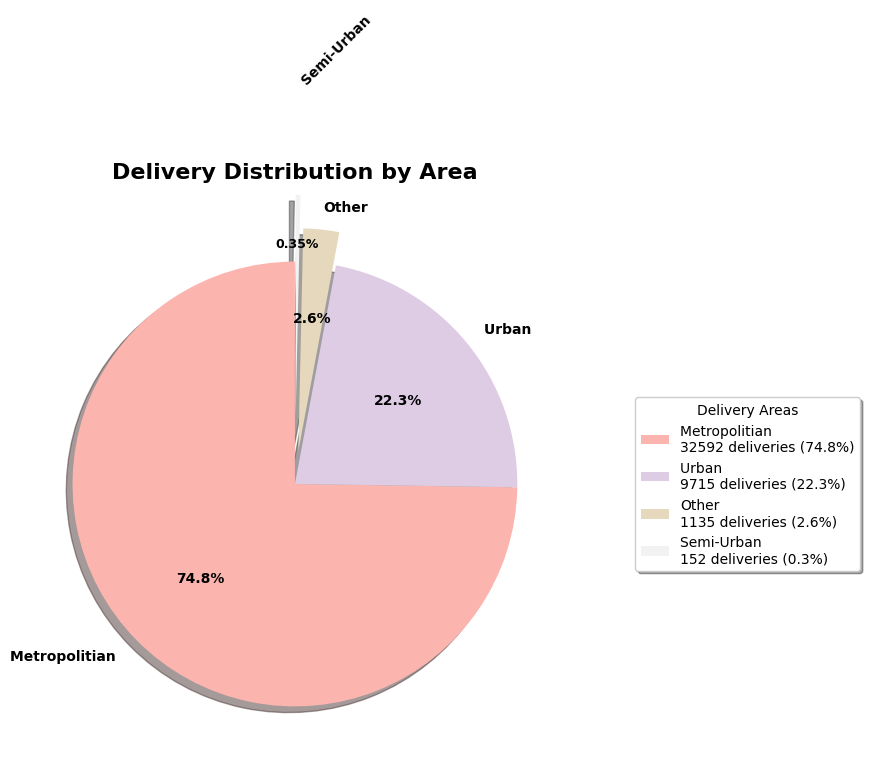

AREA DISTRIBUTION SUMMARY
Metropolitian   32,592 deliveries ( 74.8%)
Urban            9,715 deliveries ( 22.3%)
Other            1,135 deliveries (  2.6%)
Semi-Urban         152 deliveries (  0.3%)
Total           43,594 deliveries


In [63]:
# Calculate delivery counts for pie chart
area_counts = df['area'].value_counts()
colors = plt.cm.Pastel1(np.linspace(0, 1, len(area_counts)))

# More aggressive explode for very small slices
explode = []
for count in area_counts.values:
    percentage = (count / sum(area_counts.values)) * 100
    if percentage < 1:
        explode.append(0.3)  # Strong explode for very small slices
    elif percentage < 5:
        explode.append(0.15)  # Moderate explode for small slices
    else:
        explode.append(0)  # No explode for large slices

# Create figure with adjusted size
plt.figure(figsize=(12, 8))

# Create the pie chart
wedges, texts, autotexts = plt.pie(
    area_counts.values,
    labels=area_counts.index,
    autopct=lambda pct: f'{pct:.1f}%' if pct >= 1 else f'{pct:.2f}%',  # More decimal for very small percentages
    colors=colors,
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={'fontweight': 'bold'}
)

# Enhanced label positioning
for i, (text, autotext, count) in enumerate(zip(texts, autotexts, area_counts.values)):
    percentage = (count / sum(area_counts.values)) * 100

    # Custom positioning for small slices
    if percentage < 2:
        # Rotate labels and adjust position
        text.set_rotation(45)
        text.set_ha('left')
        text.set_va('center')
        # Move labels outward
        text.set_position((text.get_position()[0] * 1.4, text.get_position()[1] * 1.4))

        # Also adjust percentage text position
        autotext.set_position((autotext.get_position()[0] * 1.2, autotext.get_position()[1] * 1.2))
        autotext.set_fontsize(9)  # Smaller font for very small percentages

plt.title('Delivery Distribution by Area', fontweight='bold', fontsize=16, pad=20)

# Add a nice legend
legend_labels = [f'{label}\n{count} deliveries ({count/sum(area_counts.values)*100:.1f}%)'
                for label, count in zip(area_counts.index, area_counts.values)]

plt.legend(wedges, legend_labels,
          title="Delivery Areas",
          loc="center left",
          bbox_to_anchor=(1.1, 0.5),
          frameon=True,
          fancybox=True,
          shadow=True)

plt.tight_layout()
plt.subplots_adjust(right=0.65)
plt.show()

# Print summary statistics
print("="*50)
print("AREA DISTRIBUTION SUMMARY")
print("="*50)
total = sum(area_counts.values)
for area, count in area_counts.items():
    percentage = (count / total) * 100
    print(f"{area:15} {count:6,} deliveries ({percentage:5.1f}%)")
print(f"{'Total':15} {total:6,} deliveries")

**Key Insights**
**Dominance of Metropolitan Areas:** Deliveries in Metropolitan areas account for almost three-quarters (74.8%) of the entire distribution, making it the most critical segment by volume.

  * **High Concentration:** The combination of Metropolitan and Urban areas represents a commanding 97.1% of all deliveries (74.8%+22.3%). This indicates that the delivery service is highly focused on, or primarily serves, densely populated city environments.

  * **Marginality of Other Areas:**'Other' and 'Semi-Urban' areas collectively make up less than 3% of the total volume. Specifically, Semi-Urban areas account for a mere 0.35% (152 deliveries), suggesting very limited or nascent operations in these less dense regions.

### **Chart - 4**

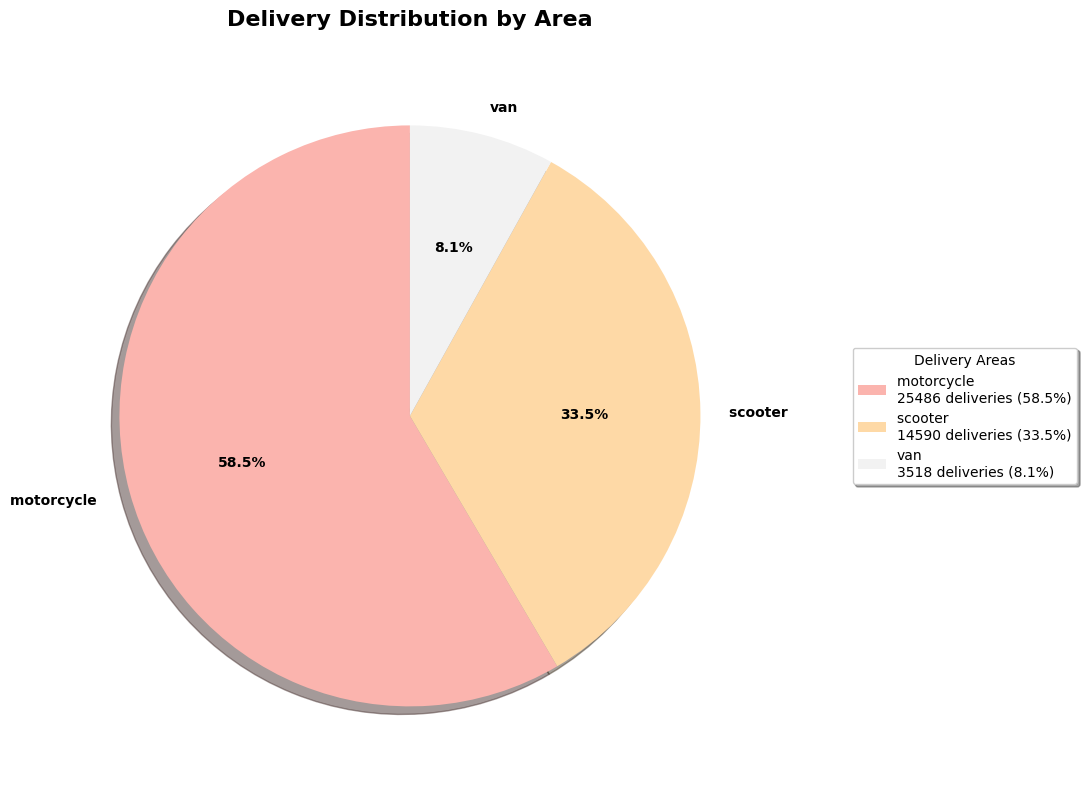

AREA DISTRIBUTION SUMMARY
motorcycle      25,486 deliveries ( 58.5%)
scooter         14,590 deliveries ( 33.5%)
van              3,518 deliveries (  8.1%)
Total           43,594 deliveries


In [64]:
# Calculate delivery counts for pie chart
area_counts = df['vehicle'].value_counts()
colors = plt.cm.Pastel1(np.linspace(0, 1, len(area_counts)))

# More aggressive explode for very small slices
explode = []
for count in area_counts.values:
    percentage = (count / sum(area_counts.values)) * 100
    if percentage < 1:
        explode.append(0.3)  # Strong explode for very small slices
    elif percentage < 5:
        explode.append(0.15)  # Moderate explode for small slices
    else:
        explode.append(0)  # No explode for large slices

# Create figure with adjusted size
plt.figure(figsize=(12, 8))

# Create the pie chart
wedges, texts, autotexts = plt.pie(
    area_counts.values,
    labels=area_counts.index,
    autopct=lambda pct: f'{pct:.1f}%' if pct >= 1 else f'{pct:.2f}%',  # More decimal for very small percentages
    colors=colors,
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={'fontweight': 'bold'}
)

# Enhanced label positioning
for i, (text, autotext, count) in enumerate(zip(texts, autotexts, area_counts.values)):
    percentage = (count / sum(area_counts.values)) * 100

    # Custom positioning for small slices
    if percentage < 2:
        # Rotate labels and adjust position
        text.set_rotation(45)
        text.set_ha('left')
        text.set_va('center')
        # Move labels outward
        text.set_position((text.get_position()[0] * 1.4, text.get_position()[1] * 1.4))

        # Also adjust percentage text position
        autotext.set_position((autotext.get_position()[0] * 1.2, autotext.get_position()[1] * 1.2))
        autotext.set_fontsize(9)  # Smaller font for very small percentages

plt.title('Delivery Distribution by Area', fontweight='bold', fontsize=16, pad=20)

# Add a nice legend
legend_labels = [f'{label}\n{count} deliveries ({count/sum(area_counts.values)*100:.1f}%)'
                for label, count in zip(area_counts.index, area_counts.values)]

plt.legend(wedges, legend_labels,
          title="Delivery Areas",
          loc="center left",
          bbox_to_anchor=(1.1, 0.5),
          frameon=True,
          fancybox=True,
          shadow=True)

plt.tight_layout()
plt.subplots_adjust(right=0.65)
plt.show()

# Print summary statistics
print("="*50)
print("AREA DISTRIBUTION SUMMARY")
print("="*50)
total = sum(area_counts.values)
for area, count in area_counts.items():
    percentage = (count / total) * 100
    print(f"{area:15} {count:6,} deliveries ({percentage:5.1f}%)")
print(f"{'Total':15} {total:6,} deliveries")

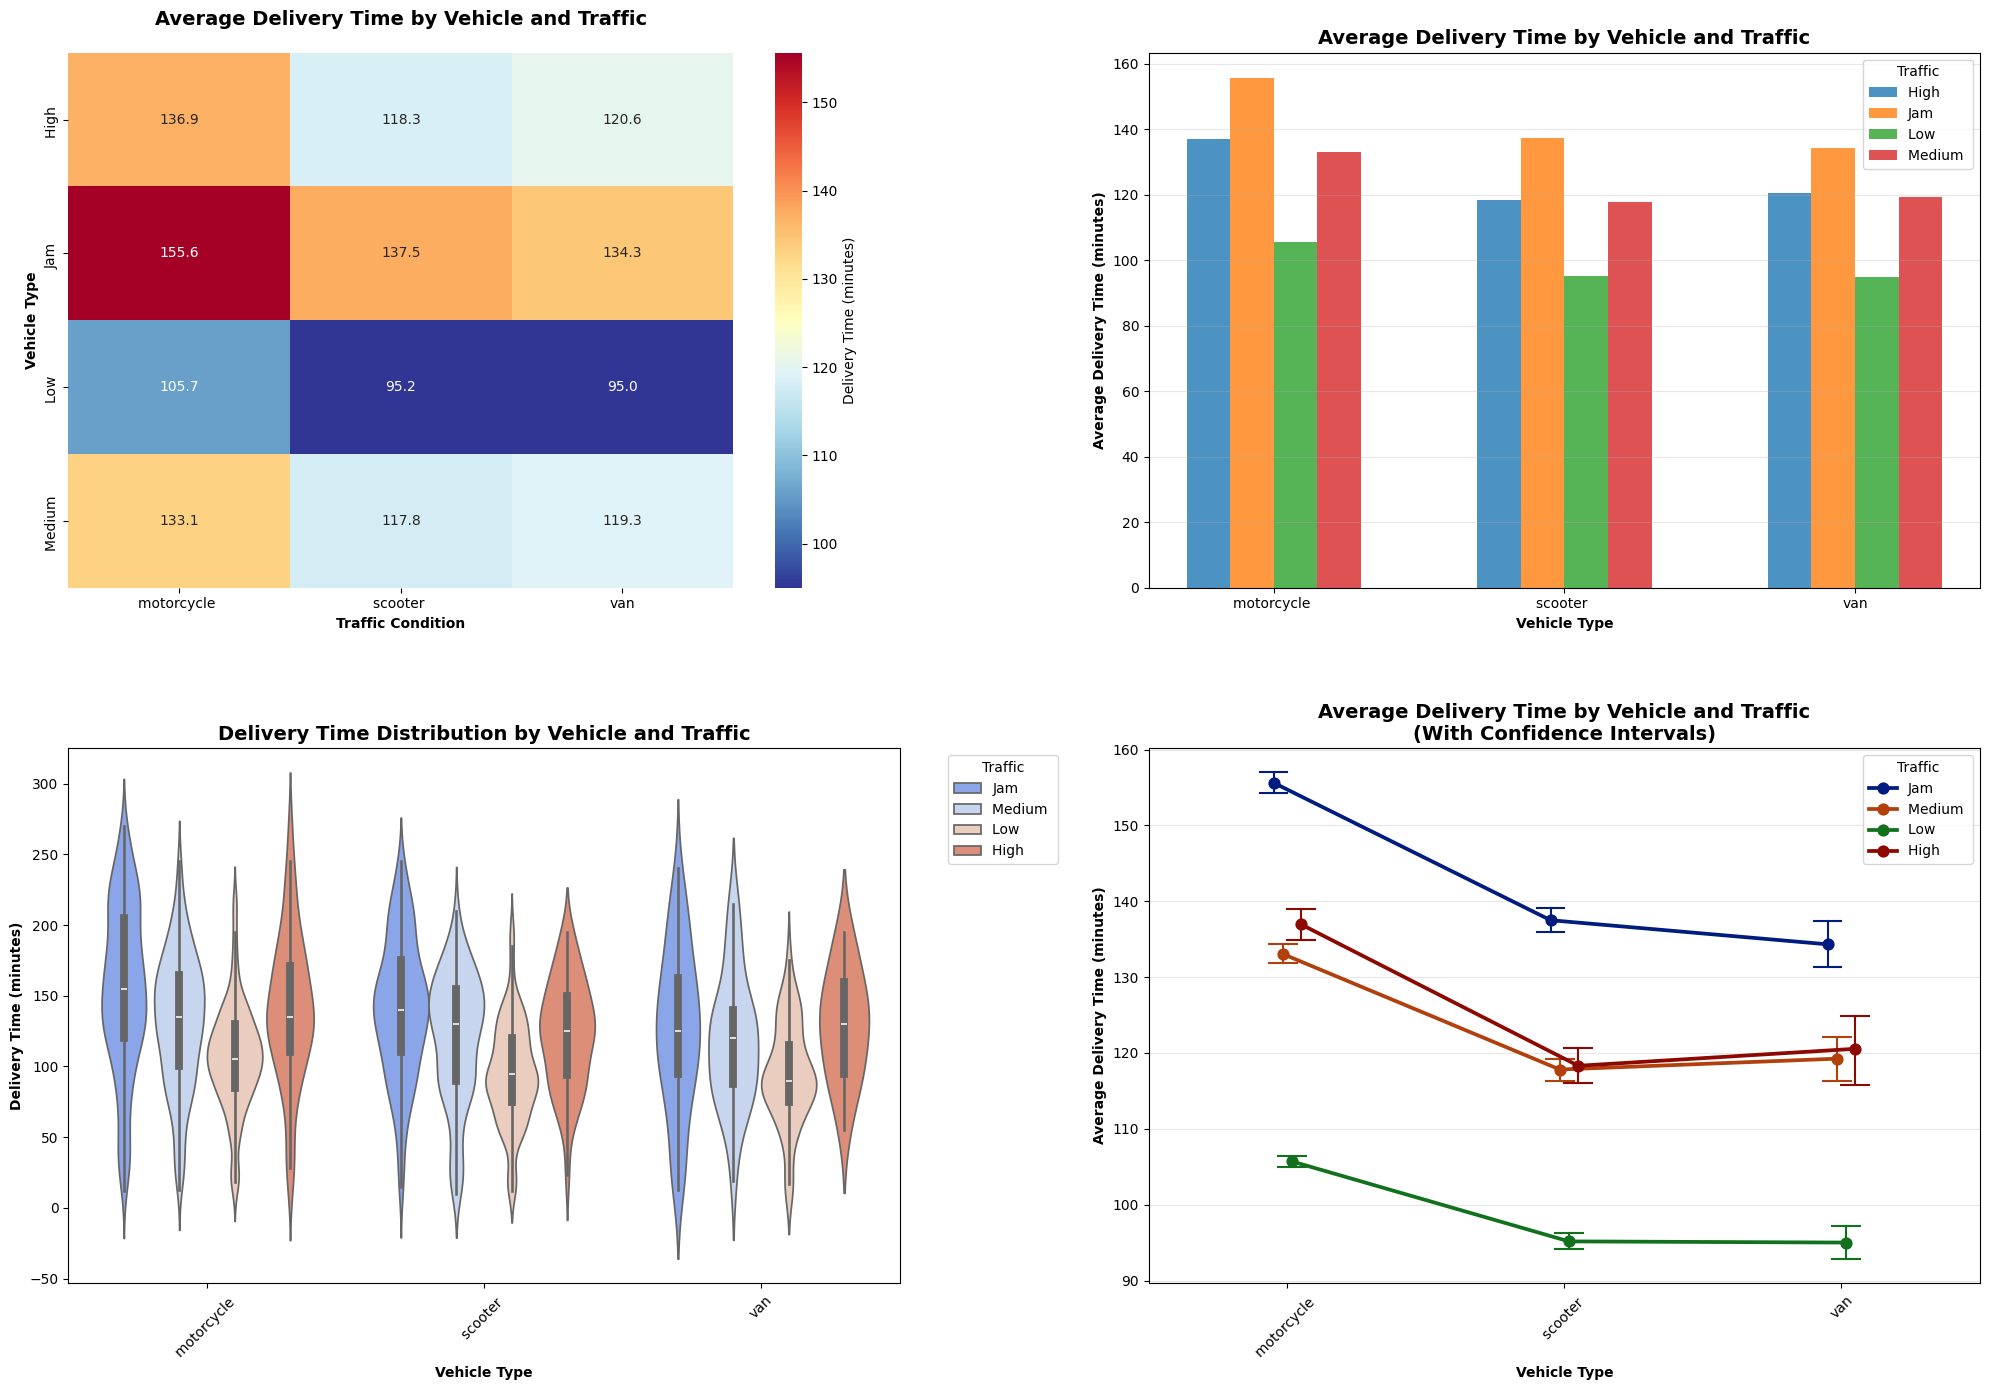

In [65]:
# Create a 2x2 subplot for vehicle, traffic and delivery time analysis
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# =============================================================================
# 2.1 Heatmap: Average Delivery Time by Vehicle and Traffic
# =============================================================================
pivot_vehicle_traffic = df.pivot_table(
    values='delivery_time',
    index='traffic',
    columns='vehicle',
    aggfunc='mean'
)

sns.heatmap(pivot_vehicle_traffic, annot=True, fmt=".1f", cmap='RdYlBu_r',
            ax=axes[0, 0], cbar_kws={'label': 'Delivery Time (minutes)'})
axes[0, 0].set_title('Average Delivery Time by Vehicle and Traffic',
                     fontweight='bold', fontsize=14, pad=20)
axes[0, 0].set_xlabel('Traffic Condition', fontweight='bold')
axes[0, 0].set_ylabel('Vehicle Type', fontweight='bold')

# =============================================================================
# 2.2 Grouped Bar Chart: Delivery Time by Vehicle and Traffic
# =============================================================================
# Prepare data for grouped bar chart
vehicle_traffic_data = df.groupby(['vehicle', 'traffic'])['delivery_time'].mean().reset_index()

# Create grouped bar chart
x = np.arange(len(vehicle_traffic_data['vehicle'].unique()))
width = 0.15
traffic_conditions = vehicle_traffic_data['traffic'].unique()

for i, traffic in enumerate(traffic_conditions):
    traffic_data = vehicle_traffic_data[vehicle_traffic_data['traffic'] == traffic]
    values = [traffic_data[traffic_data['vehicle'] == vehicle]['delivery_time'].values[0]
              if vehicle in traffic_data['vehicle'].values else 0
              for vehicle in vehicle_traffic_data['vehicle'].unique()]

    axes[0, 1].bar(x + i*width, values, width, label=traffic, alpha=0.8)

axes[0, 1].set_xlabel('Vehicle Type', fontweight='bold')
axes[0, 1].set_ylabel('Average Delivery Time (minutes)', fontweight='bold')
axes[0, 1].set_title('Average Delivery Time by Vehicle and Traffic',
                     fontweight='bold', fontsize=14)
axes[0, 1].set_xticks(x + width*(len(traffic_conditions)-1)/2)
axes[0, 1].set_xticklabels(vehicle_traffic_data['vehicle'].unique())
axes[0, 1].legend(title='Traffic')
axes[0, 1].grid(axis='y', alpha=0.3)

# =============================================================================
# 2.3 Violin Plot: Delivery Time Distribution by Vehicle and Traffic
# =============================================================================
# Create a subset for better violin plot visualization
sample_df_violin = df.sample(min(3000, len(df))) if len(df) > 3000 else df

sns.violinplot(data=sample_df_violin, x='vehicle', y='delivery_time', hue='traffic',
               ax=axes[1, 0], palette='coolwarm', split=False)
axes[1, 0].set_title('Delivery Time Distribution by Vehicle and Traffic',
                     fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Vehicle Type', fontweight='bold')
axes[1, 0].set_ylabel('Delivery Time (minutes)', fontweight='bold')
axes[1, 0].legend(title='Traffic', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 0].tick_params(axis='x', rotation=45)

# =============================================================================
# 2.4 Line Plot: Delivery Time Trends by Vehicle and Traffic
# =============================================================================
# Assuming we have time data or can create an index
# If not, we'll use point plot instead
sns.pointplot(data=df, x='vehicle', y='delivery_time', hue='traffic',
              ax=axes[1, 1], palette='dark', dodge=True, errwidth=1.5, capsize=0.1)
axes[1, 1].set_title('Average Delivery Time by Vehicle and Traffic\n(With Confidence Intervals)',
                     fontweight='bold', fontsize=14)
axes[1, 1].set_xlabel('Vehicle Type', fontweight='bold')
axes[1, 1].set_ylabel('Average Delivery Time (minutes)', fontweight='bold')
axes[1, 1].legend(title='Traffic')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

The two plots provided—a **Violin Plot** and a **Line Plot** with confidence intervals—analyze the relationship between **Vehicle Type**, **Traffic Condition**, and **Delivery Time**.

***

## 1. Delivery Time Distribution by Vehicle and Traffic (Violin Plot)

The violin plot illustrates the full distribution of delivery times for each combination of vehicle and traffic condition, showing the density of data points (the 'violin' shape) and the median (the white dot) and interquartile range (the thick black bar).

### Key Findings from the Violin Plot:

* **Longest Delays (Jam Traffic):** For every vehicle type (Scooter, Motorcycle, Van), the **Jam Traffic** distribution (red/brown violins) is positioned highest on the Y-axis and is generally the broadest at the top. This confirms that Jam Traffic universally leads to the **highest median delivery times** and the longest maximum times ($\approx 250$ to $280$ minutes).
* **Fastest Deliveries (Low Traffic):** The **Low Traffic** distribution (blue violins) consistently sits lowest on the Y-axis across all vehicles, indicating the **shortest median and overall delivery times**.
* **Van Performance:** The Van shows the least variation in its median delivery time across the different traffic conditions, especially between Medium, High, and Jam traffic, suggesting its performance is relatively **more resilient** to traffic congestion compared to the other vehicles.
* **Motorcycle Variability:** The Motorcycle shows a slightly wider distribution (more variability) in the upper ranges for Jam and High traffic compared to the Scooter and Van, implying a greater chance of very long delays under severe congestion.

***

## 2. Average Delivery Time by Vehicle and Traffic (Line Plot)

The line plot provides a clear, quantitative view of the **mean delivery time** for each vehicle and traffic combination, complete with **95% confidence intervals** (error bars).

### Key Findings from the Line Plot:

* **Traffic Impact is Dominant:** Delivery time is most heavily influenced by **Traffic Condition**, as evidenced by the clear vertical separation of the four trend lines.
    * **Jam Traffic** (highest line) always results in the longest average time (135–155 minutes).
    * **Low Traffic** (lowest line) always results in the shortest average time (95–105 minutes).
* **Vehicle Performance Under Congestion:**
    * Under **Jam Traffic**, the **Motorcycle** is significantly slower ($\approx 155$ min) than the **Scooter** ($\approx 138$ min) and **Van** ($\approx 135$ min).
    * Under **High** and **Medium** traffic, the **Scooter** and **Van** perform almost identically and are slightly faster than the Motorcycle.
* **Vehicle Performance Under Low Traffic:** All three vehicles perform best under Low Traffic, with the **Scooter** and **Van** having nearly identical and the lowest average times ($\approx 95$ minutes), while the **Motorcycle** is slightly slower ($\approx 105$ minutes).
* **Overall Best Performer:** The **Scooter** and **Van** show the most consistent and overall shortest average delivery times, especially under congested (High/Jam) conditions. The **Motorcycle** is noticeably penalized in Jam Traffic.

In summary, traffic condition is the primary determinant of delivery time. While all vehicles suffer in high traffic, the **Scooter** and **Van** demonstrate a slight but consistent edge in efficiency and resilience over the Motorcycle in most traffic conditions.

### **Chart - 5**

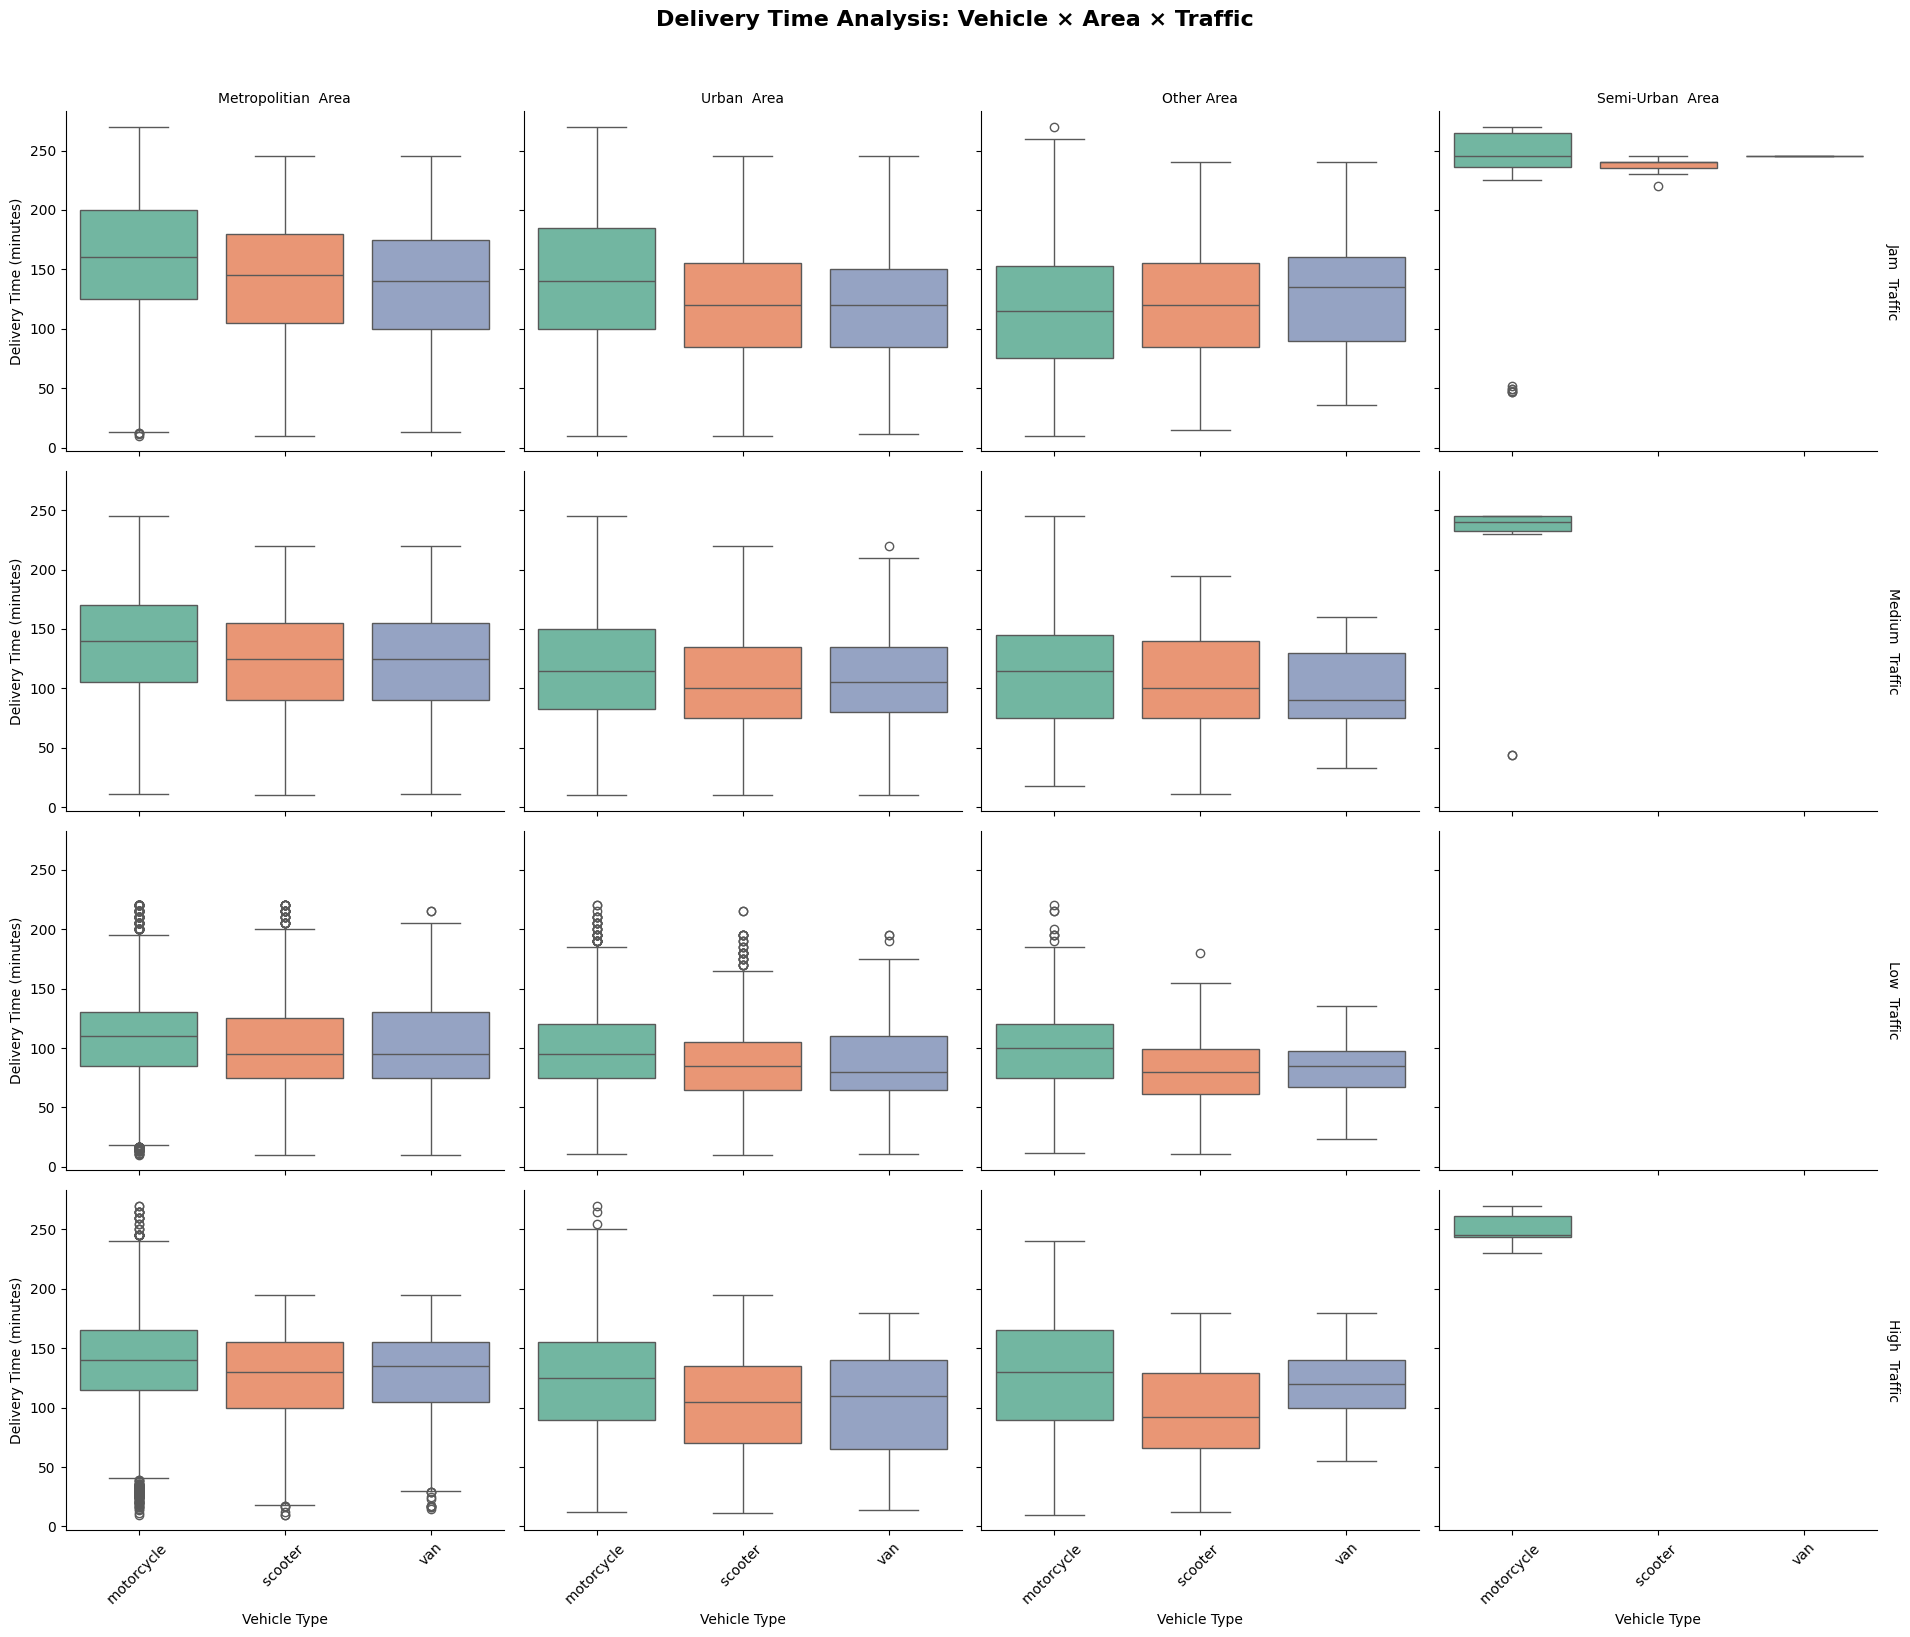

In [66]:
# Facet Grid: Vehicle × Area × Traffic
g = sns.FacetGrid(df, col='area', row='traffic',
                  margin_titles=True, height=4, aspect=1.2)

# ✅ Better color tone (try 'Set2', 'Paired', 'husl', 'Dark2')
g.map_dataframe(
    sns.boxplot,
    x='vehicle', y='delivery_time',
    palette='Set2',  # <-- change palette here
    order=df['vehicle'].unique()
)

g.set_titles(col_template="{col_name} Area", row_template="{row_name} Traffic")
g.set_axis_labels("Vehicle Type", "Delivery Time (minutes)")
g.fig.suptitle(
    'Delivery Time Analysis: Vehicle × Area × Traffic',
    fontweight='bold', fontsize=16, y=1.02
)

# Rotate x-axis labels
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Here’s a **clear write-up** for the two attached visualizations you generated with the Seaborn `FacetGrid` boxplots. You can adapt this as part of your report or presentation:

---

### **Delivery Time Analysis: Vehicle × Area × Traffic**

The attached boxplots provide a detailed comparative view of **delivery times across different vehicles, areas, and traffic conditions**. Using Seaborn’s `FacetGrid`, the data is split into panels (facets) by **traffic levels (rows)** and **area categories (columns)**, while boxplots show how different vehicle types perform under each condition.

#### **Key Observations**

1. **Traffic Effect on Delivery Time**

   * Delivery times generally increase with traffic congestion (Low → Medium → High → Jam).
   * In high-traffic and jammed conditions, variability also increases, with wider interquartile ranges and more outliers, especially for motorcycles.

2. **Area-Wise Performance**

   * **Metropolitan & Urban Areas**: Delivery times are more consistent, with motorcycles, scooters, and vans showing overlapping ranges.
   * **Semi-Urban Areas**: Deliveries tend to take longer, especially under jam traffic, where motorcycles dominate but with high variability.
   * **Other Areas**: Delivery times are relatively stable across vehicle types, though motorcycles still show slightly higher median times.

3. **Vehicle-Wise Insights**

   * **Motorcycles**: While widely used, they show the highest variance in delivery times, especially in congested areas.
   * **Scooters**: Perform slightly better in congested zones, with tighter interquartile ranges.
   * **Vans**: Deliveries with vans are slower on average but more consistent, especially in medium to low traffic zones.

4. **Outliers**

   * Several extreme delivery times appear across categories, reflecting occasional delays possibly due to **weather, route issues, or operational inefficiencies**.

#### **Visualization Design**

* A **FacetGrid layout** allows for simultaneous comparison across traffic (rows) and area types (columns).
* A **categorical palette (Set2)** provides distinct yet visually balanced tones for each vehicle type.
* Rotated x-axis labels improve readability in multi-panel layouts.




### **Chart - 6**

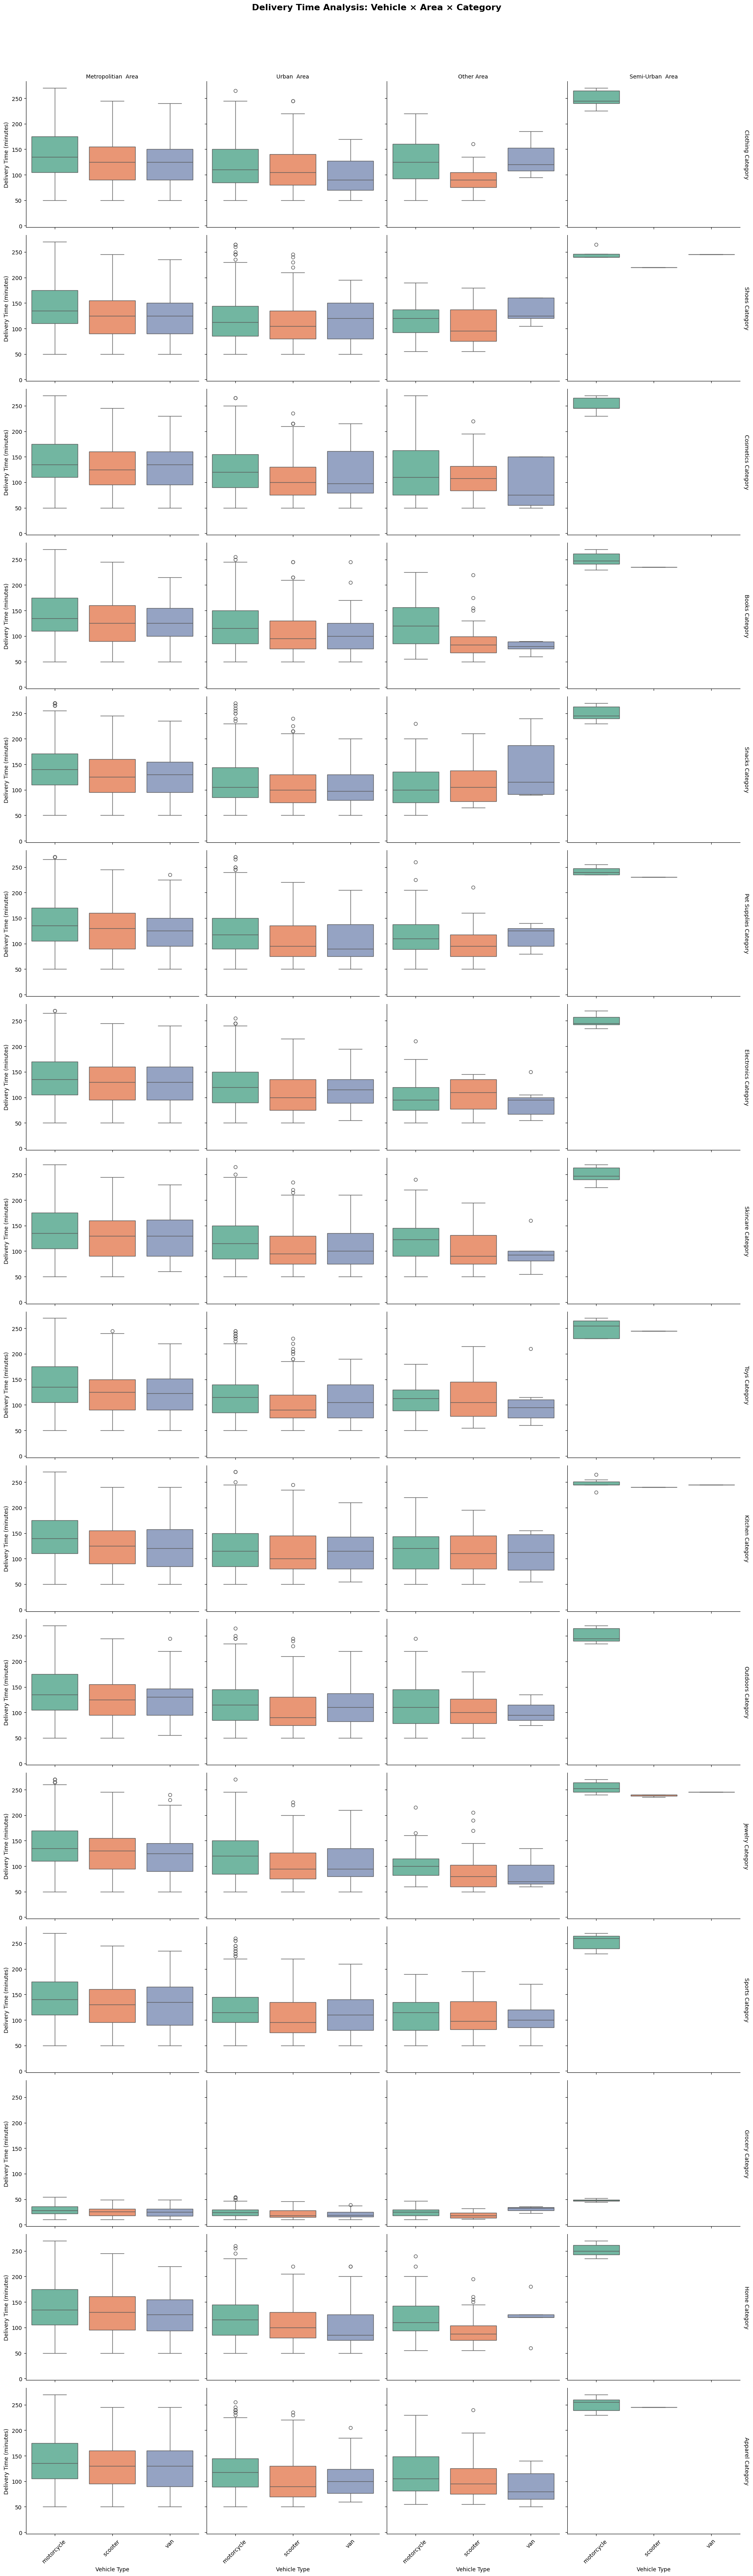

In [67]:
# Facet Grid: Vehicle × Area × Traffic
g = sns.FacetGrid(df, col='area', row='category',
                  margin_titles=True, height=4, aspect=1.2)

# ✅ Better color tone (try 'Set2', 'Paired', 'husl', 'Dark2')
g.map_dataframe(
    sns.boxplot,
    x='vehicle', y='delivery_time',
    palette='Set2',  # <-- change palette here
    order=df['vehicle'].unique()
)

g.set_titles(col_template="{col_name} Area", row_template="{row_name} Category")
g.set_axis_labels("Vehicle Type", "Delivery Time (minutes)")
g.fig.suptitle(
    'Delivery Time Analysis: Vehicle × Area × Category',
    fontweight='bold', fontsize=16, y=1.02
)

# Rotate x-axis labels
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


The images provided display a complex **Facet Grid** analysis of **Delivery Time** segmented across three dimensions: **Vehicle Type (x-axis)**, **Area (columns)**, and **Product Category (rows)**. Each subplot is a box plot showing the distribution of delivery times for the specific combination.

The overall layout is as follows:
* **Columns (Area):** Metropolitan, Urban, Other, Semi-Urban
* **Rows (Category):** The first image shows 'Home' and 'Apparel' categories. The second image shows 'Clothing' and 'Shoes' categories. (Note: The prompt suggests the rows are consistent, but the images show different categories across them, which is likely a data visualization artifact or a partial view of a larger grid).

Assuming the columns represent the same areas across both visible segments, here is the combined analysis:

***

## 1. General Trends Across Categories and Vehicles

In the high-volume areas (**Metropolitan** and **Urban**), the delivery time distributions are remarkably similar across **Motorcycle**, **Scooter**, and **Van**, regardless of the category:

* **Vehicle Performance:** **Scooters** and **Vans** consistently show a slightly **lower median delivery time** (shorter white line in the box) and a tighter interquartile range (IQR, the middle box) compared to Motorcycles. This suggests they are marginally more reliable and faster in high-density areas.
* **Median Time:** The median delivery time in Metropolitan and Urban areas generally sits around **100 minutes** (1 hour 40 minutes) for all categories and vehicles.
* **Outliers:** All combinations show a significant number of outliers (individual circles) extending up to **250 minutes** and beyond, indicating that all deliveries are susceptible to extreme delays.

***

## 2. Impact of Area on Delivery Time

The most dramatic effect on delivery time is caused by the **Area** of delivery, particularly in low-volume areas.

| Area | Key Observation | Median Time (Approx.) |
| :--- | :--- | :--- |
| **Metropolitan/Urban** | Consistent performance across categories and vehicles. Moderate delivery times. | $\approx 100$ minutes |
| **Other Area** | Delivery times remain similar to Metropolitan/Urban for Scooter and Van, but **Motorcycle** shows a higher median and wider IQR, suggesting less efficiency. | $\approx 100$ minutes |
| **Semi-Urban Area** | This area exhibits extreme delivery times, with very narrow distributions far up the Y-axis. The median time jumps drastically, showing severe operational challenges. | $\approx 240$ minutes |

***

## 3. Extreme Delays in Semi-Urban Areas

The column representing the **Semi-Urban Area** stands out as the biggest area of concern:

* For the **Clothing** and **Home** categories, the median delivery time for **Motorcycles** is exceptionally high, sitting near **250 minutes** (over 4 hours).
* For **Scooters** and **Vans** in the Semi-Urban area, data is either non-existent (empty plots) or represented by a single, high data point (a narrow line instead of a box), confirming that very few, if any, deliveries occur, and those that do are extremely delayed.

This suggests that the delivery service has **significant operational problems** in Semi-Urban regions, likely due to low volume, long distances, and poor logistics, resulting in exceptionally long delivery times for the few orders received.

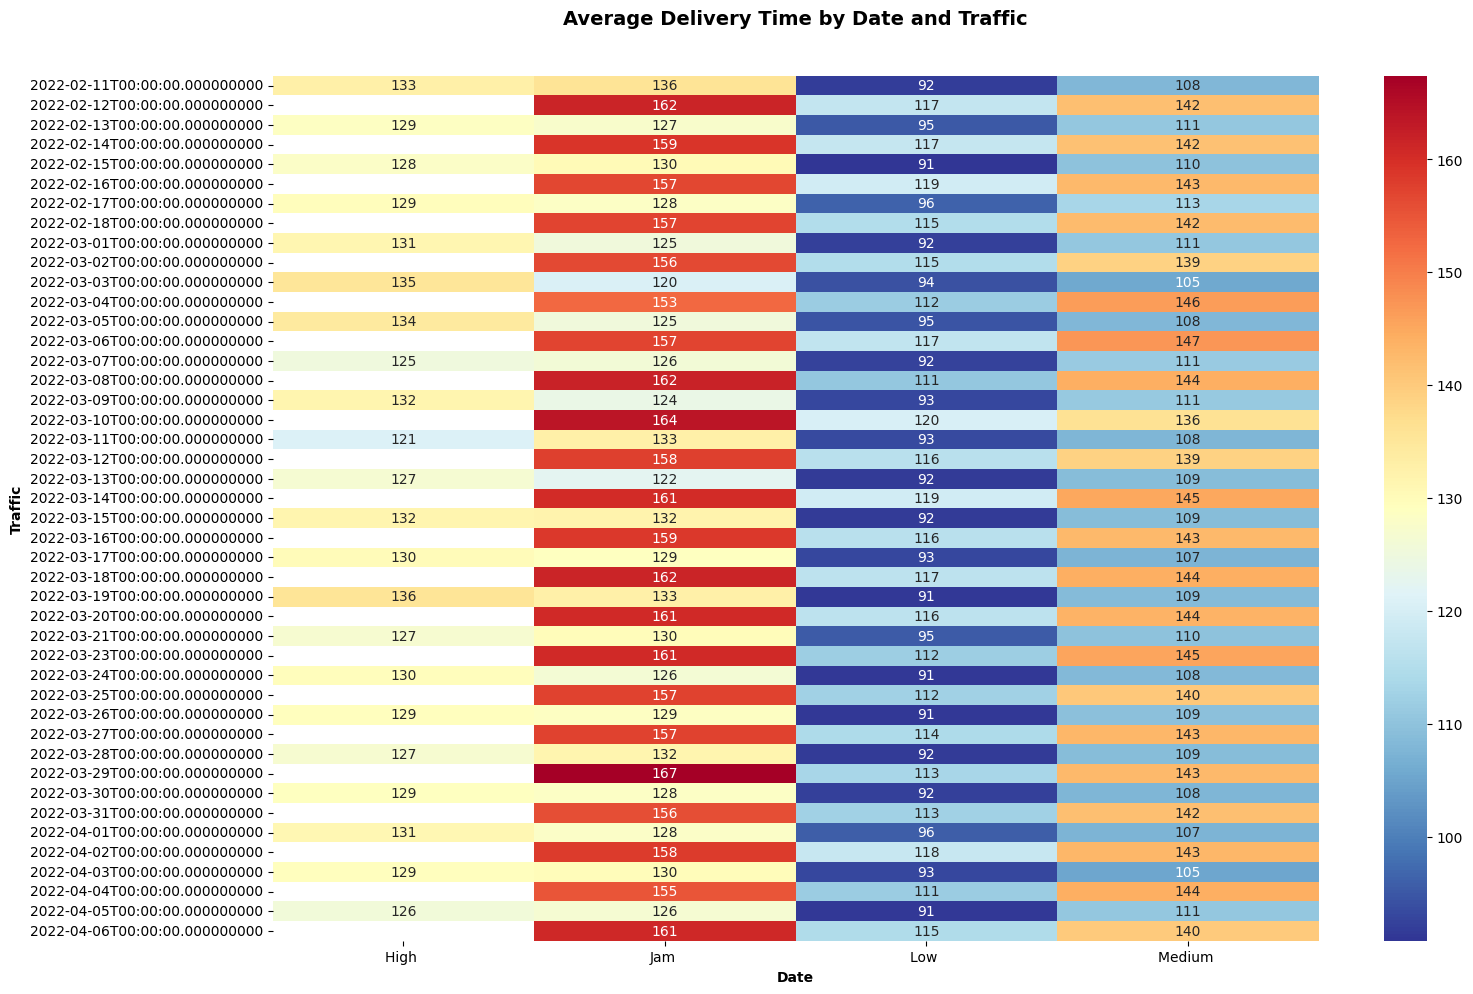

In [68]:
# Create pivot table with mean delivery time per date and traffic
pivot_table = df.pivot_table(
    values='delivery_time',
    index='order_date',
    columns='traffic',
    aggfunc='mean'
)

# Create a single subplot with optimized size
fig, ax = plt.subplots(1, 1, figsize=(16, 10))  # Reduced from (24, 34)

# =============================================================================
# 1. HEATMAP - Average Delivery Time by Date and Traffic
# =============================================================================
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='RdYlBu_r', ax=ax)
ax.set_title('Average Delivery Time by Date and Traffic', fontweight='bold', fontsize=14, y=1.05)
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Traffic', fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.show()

### **Chart - 7**

In [69]:
df.columns

Index(['agent_age', 'agent_rating', 'store_latitude', 'store_longitude',
       'drop_latitude', 'drop_longitude', 'order_date', 'order_time',
       'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time',
       'category', 'order_year', 'order_month', 'order_day', 'day_name'],
      dtype='object')

In [70]:
import plotly.express as px
import pandas as pd

# Suppose your dataframe is named df and has columns 'latitude' and 'longitude'
fig = px.scatter_geo(df, lat='store_latitude', lon='store_longitude')#, hover_name="store_name")
fig.update_layout(title='Store Locations', title_x=0.5)
fig.show()


**Specific Areas**:

  * **South Asia:** A significant cluster of dots covers India, Bangladesh, and neighboring countries like Nepal and Sri Lanka.

  * **Indian Ocean/Southeast Asia:** A distinct line of dots extends south and slightly east of India, covering a chain of islands in the Indian Ocean, which likely includes the Maldives and potentially parts of the archipelagos leading towards Southeast Asia.

  * **Africa:** There is one isolated dot on the eastern coast of Africa, likely near Tanzania or Kenya.

  * **Other:** There are one or two very small dots in the ocean west of Africa and another isolated one further south in the Indian Ocean.



In [71]:
# Suppose your dataframe is named df and has columns 'latitude' and 'longitude'
fig = px.scatter_geo(df, lat='drop_latitude', lon='drop_longitude')#, hover_name="store_name")
fig.update_layout(title='Store Locations', title_x=0.5)
fig.show()


The areas on the map with blue dots, representing "DROP Locations," are primarily concentrated in **South Asia** and the **Western Indian Ocean**.

* **South Asia (Indian Subcontinent):** The largest cluster of dots is heavily concentrated across the country of **India**, extending into **Bangladesh** and potentially bordering regions of **Nepal** and **Sri Lanka**.
* **Indian Ocean/East Africa:** There is one isolated dot off the eastern coast of **Africa**, likely representing a location such as the **Seychelles** or **Mauritius** islands, or possibly a location on the East African mainland near countries like **Tanzania** or **Kenya**.

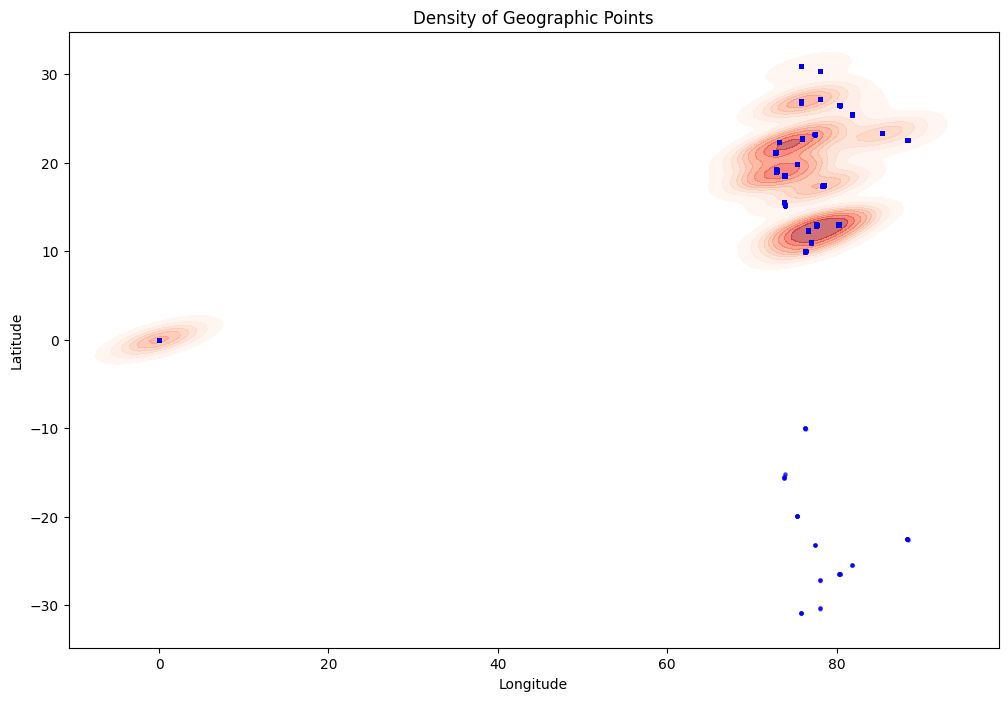

In [72]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.kdeplot(
    x=df['store_longitude'],
    y=df['store_latitude'],
    cmap='Reds',
    fill=True,
    thresh=0.05,
    alpha=0.6
)

plt.scatter(df['store_longitude'], df['store_latitude'], alpha=0.2, s=5, color='blue')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Density of Geographic Points')
plt.show()


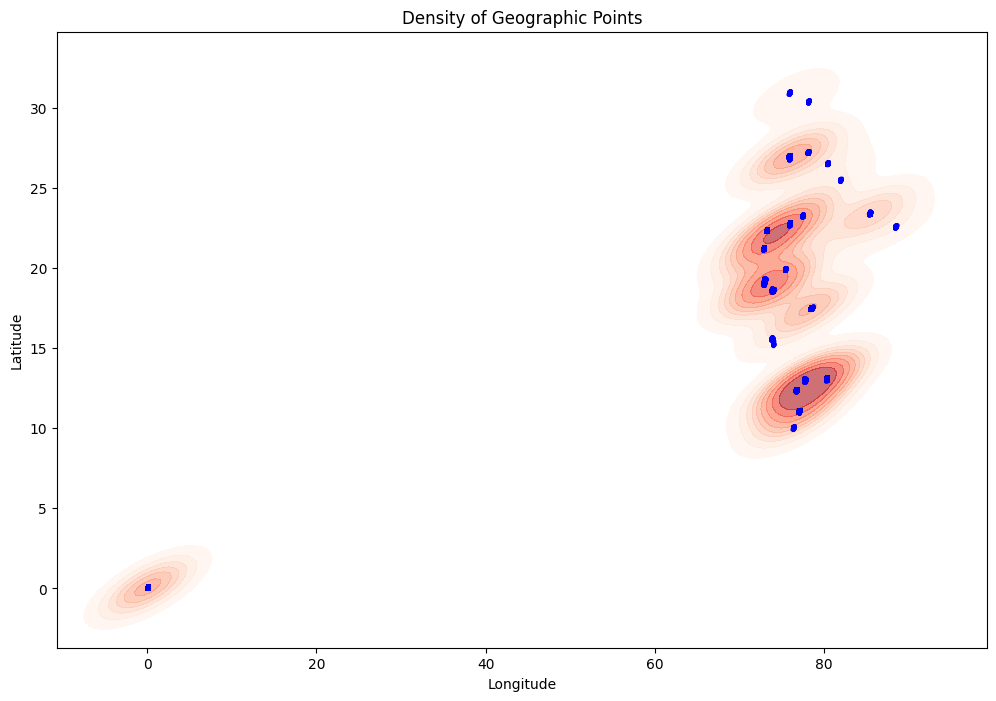

In [73]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.kdeplot(
    x=df['drop_longitude'],
    y=df['drop_latitude'],
    cmap='Reds',
    fill=True,
    thresh=0.05,
    alpha=0.6
)

plt.scatter(df['drop_longitude'], df['drop_latitude'], alpha=0.2, s=5, color='blue')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Density of Geographic Points')
plt.show()

In [74]:
df.columns

Index(['agent_age', 'agent_rating', 'store_latitude', 'store_longitude',
       'drop_latitude', 'drop_longitude', 'order_date', 'order_time',
       'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time',
       'category', 'order_year', 'order_month', 'order_day', 'day_name'],
      dtype='object')


       'order_date', 'order_time',
       'pickup_time','Coordinates'

### **Chart - 8**

In [156]:
df

,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category,order_year,order_month,order_day,day_name,time_to_deliver
36718,37,4.7,27.158822,78.045359,27.208822,78.095359,2022-02-11,0 days 19:15:00,0 days 19:20:00,Windy,Jam,motorcycle,Metropolitian,145,Clothing,2022,2,2022-02-11,Friday,0 days 00:05:00
31233,26,4.9,22.527893,88.368628,22.567893,88.408628,2022-02-11,0 days 16:00:00,0 days 16:05:00,Fog,Medium,motorcycle,Urban,55,Shoes,2022,2,2022-02-11,Friday,0 days 00:05:00
31237,27,4.8,23.233219,77.433571,23.253219,77.453571,2022-02-11,0 days 09:00:00,0 days 09:10:00,Sunny,Low,scooter,Urban,120,Shoes,2022,2,2022-02-11,Friday,0 days 00:10:00
18091,24,4.7,9.979363,76.285001,10.009363,76.315001,2022-02-11,0 days 18:25:00,0 days 18:30:00,Cloudy,Medium,scooter,Metropolitian,70,Clothing,2022,2,2022-02-11,Friday,0 days 00:05:00
18061,27,4.8,30.893081,75.821495,30.903081,75.831495,2022-02-11,0 days 09:20:00,0 days 09:25:00,Fog,Low,scooter,Metropolitian,85,Cosmetics,2022,2,2022-02-11,Friday,0 days 00:05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41023,26,4.9,17.459710,78.368855,17.529710,78.438855,2022-04-06,0 days 18:20:00,0 days 18:35:00,Sunny,Medium,motorcycle,Metropolitian,135,Outdoors,2022,4,2022-04-06,Wednesday,0 days 00:15:00
21368,22,4.7,21.149669,72.772629,21.259669,72.882629,2022-04-06,0 days 21:25:00,0 days 21:40:00,Sunny,Jam,scooter,Urban,100,Books,2022,4,2022-04-06,Wednesday,0 days 00:15:00
28977,37,4.9,21.185047,72.808590,21.295047,72.918590,2022-04-06,0 days 19:45:00,0 days 20:00:00,Sunny,Jam,motorcycle,Metropolitian,95,Outdoors,2022,4,2022-04-06,Wednesday,0 days 00:15:00
21427,22,4.6,18.520016,73.830547,18.650016,73.960547,2022-04-06,0 days 18:55:00,0 days 19:00:00,Sunny,Medium,motorcycle,Metropolitian,95,Clothing,2022,4,2022-04-06,Wednesday,0 days 00:05:00


In [169]:
# Simulate the order_date column as described (43739 entries, datetime64[ns])
n_rows = 43739
start_date = df['order_date'].min().date()
end_date = df['order_date'].max().date()

# Generate a series of random datetimes
# Create a range of possible timestamps within the period (hourly frequency)
# # time_range = pd.date_range(start=start_date, end=end_date, freq='H')
# # # Sample 43739 datetimes from this range with replacement
# # dates = np.random.choice(time_range, size=n_rows)
# # # Convert to a DataFrame
# df = pd.DataFrame({'order_date': dates})
# df['order_date'] = pd.to_datetime(df['order_date']) # Ensure correct dtype

# Prepare data for plotting: Count of orders per day
# Extract just the date part for aggregation
df['order_day'] = df['order_date'].dt.date
# Calculate daily counts
pickup_df = df.groupby(['order_date','order_day'])['pickup_hours'].mean().reset_index(name='pickup_hours')
# Convert 'order_day' back to datetime for proper plotting
pickup_df['order_day'] = pd.to_datetime(pickup_df['order_day'])
pickup_df = pickup_df.sort_values('order_date')

In [177]:
pickup_df

,order_date,order_day,pickup_hours
0,2022-02-11,2022-02-11,-0.169346
1,2022-02-12,2022-02-12,-0.350281
2,2022-02-13,2022-02-13,-0.203815
3,2022-02-14,2022-02-14,-0.568645
4,2022-02-15,2022-02-15,-0.022228
5,2022-02-16,2022-02-16,-0.393309
6,2022-02-17,2022-02-17,-0.209121
7,2022-02-18,2022-02-18,-0.368107
8,2022-03-01,2022-03-01,-0.236928
9,2022-03-02,2022-03-02,-0.503275


In [170]:
pickup_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_date    44 non-null     datetime64[ns]
 1   order_day     44 non-null     datetime64[ns]
 2   pickup_hours  44 non-null     float64       
dtypes: datetime64[ns](2), float64(1)
memory usage: 1.2 KB


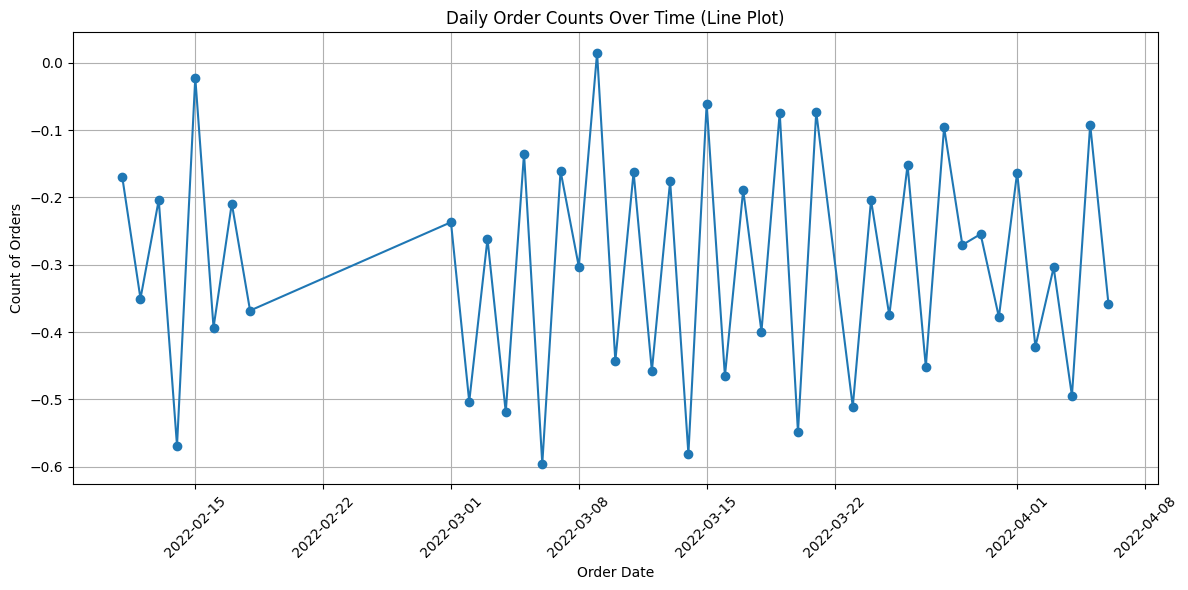

In [171]:
# 1. Line plot of order_date and count
plt.figure(figsize=(12, 6))
plt.plot(pickup_df['order_date'], pickup_df['pickup_hours'], marker='o', linestyle='-')
plt.title('Daily Order Counts Over Time (Line Plot)')
plt.xlabel('Order Date')
plt.ylabel('Count of Orders')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

In [172]:
pickup_df

,order_date,order_day,pickup_hours
0,2022-02-11,2022-02-11,-0.169346
1,2022-02-12,2022-02-12,-0.350281
2,2022-02-13,2022-02-13,-0.203815
3,2022-02-14,2022-02-14,-0.568645
4,2022-02-15,2022-02-15,-0.022228
5,2022-02-16,2022-02-16,-0.393309
6,2022-02-17,2022-02-17,-0.209121
7,2022-02-18,2022-02-18,-0.368107
8,2022-03-01,2022-03-01,-0.236928
9,2022-03-02,2022-03-02,-0.503275


In [76]:
df_model.columns

NameError: name 'df_model' is not defined

In [ ]:
df_model.info()

In [ ]:
df_model['area_freq_encoded'].value_counts()

'Coordinates',

In [143]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# # Select only numerical columns for correlation matrix
# numerical_columns = ['agent_age', 'agent_rating', 'store_latitude', 'store_longitude',
#        'drop_latitude', 'drop_longitude',  'weather', 'traffic', 'vehicle', 'area', 'delivery_time',
#        'category', 'order_year', 'order_month', 'order_day']
# #, 'delivery_time'
correlation_cols= ['agent_age', 'agent_rating', 'store_latitude', 'store_longitude',
       'drop_latitude', 'drop_longitude', 'delivery_time', 'order_year', 'order_month',
       'order_day','traffic_encoded', 'weather_encoded',
       'vehicle_scooter ', 'vehicle_van', 'area_freq_encoded', 'cat_Apparel',
       'cat_Books', 'cat_Clothing', 'cat_Cosmetics', 'cat_Electronics',
       'cat_Grocery', 'cat_Home', 'cat_Jewelry', 'cat_Kitchen', 'cat_Outdoors',
       'cat_Pet Supplies', 'cat_Shoes', 'cat_Skincare', 'cat_Snacks',
       'cat_Sports', 'cat_Toys']
# Create correlation matrix
correlation_matrix = df_model[correlation_cols].corr()

# Create custom colormap
colors = ['#DC143C', '#FFFFFF', '#2E8B57']  # Red -> White -> Green
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=100)

# Create the figure
plt.figure(figsize=(16, 12))

# Create heatmap with annotations
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle

sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap=cmap,
            center=0,
            square=True,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})

plt.title('Feature Correlation Heatmap\n(Delivery Time Analysis)',
          fontweight='bold', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.yticks(rotation=0, fontweight='bold')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

KeyError: "['weather_encoded', 'vehicle_scooter ', 'vehicle_van', 'area_freq_encoded'] not in index"

## ***5. Hypothesis Testing***

In [ ]:
from scipy.stats import shapiro
from sklearn.preprocessing import FunctionTransformer


for col in df.select_dtypes(include=['float64', 'int64']):
  # merged_df = pd.concat([df[df['credit_score'] == 'Good'][col], df[df['credit_score'] == 'Poor'][col]])
  print(f"{col} statistics")
  stat,p_value = shapiro(df[col])
  print("*"*50)
  print(f"Shapiro-Wilk Test Statistic for {col}: {stat}")
  print(f"P-value for {col}: {p_value}")
  if (p_value > 0.05):
    print_bold(f"{col} is NORMAL")#Fail to reject the null – your data are not significantly different from normal (i.e., the data can be considered normal).
  else:
    print_bold(f"Not normal")
# If p-value ≤ 0.05:
# Reject the null – your data significantly deviate from normality (i.e., your data are not normal).
  print("\n")

In [ ]:
df[df['delivery_time']==0]

In [ ]:
log_transformer = FunctionTransformer(func=np.log1p, inverse_func=np.expm1)
# log_transformer = FunctionTransformer(func=np.log1p, inverse_func=np.expm1)
for col in df.select_dtypes(include=['float64', 'int64']):
  df[col+"_log"] = log_transformer.fit_transform(df[col])
  print(f"{col}_log statistics")
  stat,p_value = shapiro(df[col+"_log"])
  print("*"*50)
  print(f"Shapiro-Wilk Test Statistic for {col}: {stat}")
  print(f"P-value for {col}_log: {p_value}")
  if (p_value > 0.05):
    print_bold(f"NORMAL")#Fail to reject the null – your data are not significantly different from normal (i.e., the data can be considered normal).
  else:
    print_bold(f"Not normal")


In [ ]:
df['sqrt_delivery_time'] = np.sqrt(df['delivery_time'])
print(f"sqrt_delivery_time statistics")
stat,p_value = shapiro(df['sqrt_delivery_time'])
print("*"*50)
print(f"Shapiro-Wilk Test Statistic for sqrt_delivery_time: {stat}")
print(f"P-value for sqrt_delivery_time: {p_value}")
if (p_value > 0.05):
  print_bold(f"{col} is NORMAL")#Fail to reject the null – your data are not significantly different from normal (i.e., the data can be considered normal).
else:
  print_bold(f"Not normal")
# If p-value ≤ 0.05:
# Reject the null – your data significantly deviate from normality (i.e., your data are not normal).


print("\n")

In [ ]:
# Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract the three main components
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day

print(f"✅ Extracted year, month, day from {len(df)} orders")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")

## ***7. ML Model Implementation***





### **ML Model - 1**

In [81]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.8 MB/s eta 0:00:00


In [130]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
from category_encoders import BinaryEncoder

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score

import numpy as np

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBRegressor

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, log_loss, roc_auc_score, classification_report, r2_score, mean_squared_error
import shap

### Using Random Forest, XGBoost, LightGBM and CatBoost	as they are robust to outliers, non-linear data and class imbalances

In [192]:
df.columns

Index(['agent_age', 'agent_rating', 'store_latitude', 'store_longitude',
       'drop_latitude', 'drop_longitude', 'order_date', 'order_time',
       'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time',
       'category', 'order_year', 'order_month', 'order_day', 'day_name',
       'time_to_deliver', 'Time_to_Pickup', 'Pickup_Hours', 'time_to_pickup',
       'pickup_hours', 'Distance_km', 'distance_km'],
      dtype='object')

In [193]:
df_model = df.dropna().copy()

In [194]:
df_model.columns

Index(['agent_age', 'agent_rating', 'store_latitude', 'store_longitude',
       'drop_latitude', 'drop_longitude', 'order_date', 'order_time',
       'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time',
       'category', 'order_year', 'order_month', 'order_day', 'day_name',
       'time_to_deliver', 'Time_to_Pickup', 'Pickup_Hours', 'time_to_pickup',
       'pickup_hours', 'Distance_km', 'distance_km'],
      dtype='object')

In [195]:
# Create a LabelEncoder instance
le_traffic = LabelEncoder()
df_model['traffic_encoded'] = le_traffic.fit_transform(df_model['traffic'])

In [196]:
# 4. Area - Frequency Encoding (handles class imbalance)
le_area = LabelEncoder()
df_model['area_encoded'] = le_area.fit_transform(df_model['area'])

In [197]:
df_model['area_encoded']

,area_encoded
36718,0
31233,3
31237,3
18091,0
18061,0
...,...
41023,0
21368,3
28977,0
21427,0


In [198]:
df_model.isna().sum()

,0
agent_age,0
agent_rating,0
store_latitude,0
store_longitude,0
drop_latitude,0
drop_longitude,0
order_date,0
order_time,0
pickup_time,0
weather,0


In [199]:
def encode_categorical_features(df_model):
    df_encoded = df_model.copy()
    print(df_encoded.columns)

    # # 1. Weather - Ordinal
    # weather_order = ['Sunny', 'Cloudy', 'Windy', 'Fog', 'Sandstorms', 'Stormy']
    # weather_mapping = {weather: i for i, weather in enumerate(weather_order)}
    # df_encoded['weather_encoded'] = df_encoded['weather'].map(weather_mapping)

    # # 2. Traffic - Ordinal with missing handling
    # traffic_order = ['Low', 'Medium', 'High', 'Jam']
    # traffic_mapping = {traffic: i for i, traffic in enumerate(traffic_order)}
    # # df_encoded['traffic_filled'] = df_encoded['traffic'].fillna('Low')  # impute with mode
    # # impute with mode
    # df_encoded['traffic_encoded'] = df_encoded['traffic_filled'].map(
    #     {traffic_mapping})

    # # 3. Vehicle - One-Hot Encoding
    # vehicle_dummies = pd.get_dummies(df_encoded['vehicle'], prefix='vehicle', drop_first=True)
    # df_encoded = pd.concat([df_encoded, vehicle_dummies], axis=1)

    # # 4. Area - Frequency Encoding (handles class imbalance)
    # area_freq = df_encoded['area'].value_counts(normalize=True)
    # df_encoded['area_freq_encoded'] = df_encoded['area'].map(area_freq)

    # 5. Category - One-Hot Encoding
    category_dummies = pd.get_dummies(df_encoded['category'], prefix='cat')
    df_encoded = pd.concat([df_encoded, category_dummies], axis=1)

    # Drop original categorical columns
    df_encoded = df_encoded.drop([ 'traffic', 'area', 'category', 'vehicle'], axis=1) #['order_id','weather']

    return df_encoded

# Apply encoding
df_model = encode_categorical_features(df_model)
print(f"Original shape: {df.shape}")
print(f"Encoded shape: {df_model.shape}")


Index(['agent_age', 'agent_rating', 'store_latitude', 'store_longitude',
       'drop_latitude', 'drop_longitude', 'order_date', 'order_time',
       'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time',
       'category', 'order_year', 'order_month', 'order_day', 'day_name',
       'time_to_deliver', 'Time_to_Pickup', 'Pickup_Hours', 'time_to_pickup',
       'pickup_hours', 'Distance_km', 'distance_km', 'traffic_encoded',
       'area_encoded'],
      dtype='object')
Original shape: (43594, 26)
Encoded shape: (43594, 40)


In [ ]:
# df_model['weather_encoded']

In [200]:
df_model.head()

,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,delivery_time,order_year,order_month,order_day,day_name,time_to_deliver,Time_to_Pickup,Pickup_Hours,time_to_pickup,pickup_hours,Distance_km,distance_km,traffic_encoded,area_encoded,cat_Apparel,cat_Books,cat_Clothing,cat_Cosmetics,cat_Electronics,cat_Grocery,cat_Home,cat_Jewelry,cat_Kitchen,cat_Outdoors,cat_Pet Supplies,cat_Shoes,cat_Skincare,cat_Snacks,cat_Sports,cat_Toys
36718,37,4.7,27.158822,78.045359,27.208822,78.095359,2022-02-11,0 days 19:15:00,0 days 19:20:00,Windy,145,2022,2,2022-02-11,Friday,0 days 00:05:00,0 days 00:05:00,0.083333,0 days 00:05:00,0.083333,7.441115,7.441115,1,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
31233,26,4.9,22.527893,88.368628,22.567893,88.408628,2022-02-11,0 days 16:00:00,0 days 16:05:00,Fog,55,2022,2,2022-02-11,Friday,0 days 00:05:00,0 days 00:05:00,0.083333,0 days 00:05:00,0.083333,6.054499,6.054499,3,3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
31237,27,4.8,23.233219,77.433571,23.253219,77.453571,2022-02-11,0 days 09:00:00,0 days 09:10:00,Sunny,120,2022,2,2022-02-11,Friday,0 days 00:10:00,0 days 00:10:00,0.166667,0 days 00:10:00,0.166667,3.020135,3.020135,2,3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
18091,24,4.7,9.979363,76.285001,10.009363,76.315001,2022-02-11,0 days 18:25:00,0 days 18:30:00,Cloudy,70,2022,2,2022-02-11,Friday,0 days 00:05:00,0 days 00:05:00,0.083333,0 days 00:05:00,0.083333,4.681943,4.681943,3,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
18061,27,4.8,30.893081,75.821495,30.903081,75.831495,2022-02-11,0 days 09:20:00,0 days 09:25:00,Fog,85,2022,2,2022-02-11,Friday,0 days 00:05:00,0 days 00:05:00,0.083333,0 days 00:05:00,0.083333,1.465204,1.465204,2,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
#  # 2. Traffic - Ordinal with missing handling
# traffic_order = ['Low', 'Medium', 'High', 'Jam']
# traffic_mapping = {i for i, traffic in enumerate(traffic_order)}
# # df_encoded['traffic_filled'] = df_encoded['traffic'].fillna('Low')  # impute with mode
# # impute with mode
# df_model['traffic_encoded'] = df_model['traffic'].map({traffic_mapping})

In [201]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43594 entries, 36718 to 28480
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   agent_age         43594 non-null  int64          
 1   agent_rating      43594 non-null  float64        
 2   store_latitude    43594 non-null  float64        
 3   store_longitude   43594 non-null  float64        
 4   drop_latitude     43594 non-null  float64        
 5   drop_longitude    43594 non-null  float64        
 6   order_date        43594 non-null  datetime64[ns] 
 7   order_time        43594 non-null  timedelta64[ns]
 8   pickup_time       43594 non-null  timedelta64[ns]
 9   weather           43594 non-null  object         
 10  delivery_time     43594 non-null  int64          
 11  order_year        43594 non-null  int32          
 12  order_month       43594 non-null  int32          
 13  order_day         43594 non-null  object         
 14  day_nam

In [ ]:
# df_model.drop(['order_id'],axis=1,inplace=True)

In [218]:
X_train, X_test, y_train, y_test = train_test_split(
    df_model.drop(['day_name','order_day','weather','order_date','delivery_time','order_time','pickup_time','order_date','weather','time_to_deliver','time_to_pickup'],axis=1), df_model['delivery_time'], test_size=0.2, random_state=42)#,'Coordinates'

In [223]:
df_model = df_model.drop(['time_to_deliver','time_to_pickup','Time_to_Pickup'],axis=1)

KeyError: "['time_to_deliver', 'time_to_pickup', 'Time_to_Pickup'] not found in axis"

In [212]:
df_model = df_model.drop(['Time_to_Pickup'],axis=1)

In [216]:
df_model = df_model.drop(['day_name'],axis=1)

In [203]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43594 entries, 36718 to 28480
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   agent_age         43594 non-null  int64          
 1   agent_rating      43594 non-null  float64        
 2   store_latitude    43594 non-null  float64        
 3   store_longitude   43594 non-null  float64        
 4   drop_latitude     43594 non-null  float64        
 5   drop_longitude    43594 non-null  float64        
 6   order_date        43594 non-null  datetime64[ns] 
 7   order_time        43594 non-null  timedelta64[ns]
 8   pickup_time       43594 non-null  timedelta64[ns]
 9   weather           43594 non-null  object         
 10  delivery_time     43594 non-null  int64          
 11  order_year        43594 non-null  int32          
 12  order_month       43594 non-null  int32          
 13  order_day         43594 non-null  object         
 14  day_nam

In [209]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34875 entries, 25414 to 41929
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   agent_age         34875 non-null  int64          
 1   agent_rating      34875 non-null  float64        
 2   store_latitude    34875 non-null  float64        
 3   store_longitude   34875 non-null  float64        
 4   drop_latitude     34875 non-null  float64        
 5   drop_longitude    34875 non-null  float64        
 6   order_year        34875 non-null  int32          
 7   order_month       34875 non-null  int32          
 8   day_name          34875 non-null  object         
 9   Time_to_Pickup    34875 non-null  timedelta64[ns]
 10  Pickup_Hours      34875 non-null  float64        
 11  pickup_hours      34875 non-null  float64        
 12  Distance_km       34875 non-null  float64        
 13  distance_km       34875 non-null  float64        
 14  traffic

In [96]:
# X_train.drop(['order_day'],axis=1,inplace=True)#,'delivery_time','order_time','pickup_time','Coordinates','order_date'],axis=1)

KeyError: "['order_day'] not found in axis"

In [ ]:
# X_test.drop(['order_day'],axis=1,inplace=True)

In [ ]:
# df_model.drop(['Coordinates','order_date'],axis=1,inplace=True)#'order_time','pickup_time']

'order_id'

### **ML Model - 2**

In [236]:
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [219]:
model_xgb = XGBRegressor(max_depth=7,
    learning_rate=0.01,
    n_estimators=1500,
    enable_categorical='True')

model_xgb.fit(X_train, y_train)
y_pred_train = model_xgb.predict(X_train)
y_pred_test = model_xgb.predict(X_test)

In [220]:
# Identify object columns that need encoding
object_columns = X_train.select_dtypes(include=['object']).columns
print("Object columns to encode:", object_columns.tolist())

# Convert object columns to category dtype
for col in object_columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Now train the model
model_xgb = XGBRegressor(
    max_depth=7,
    learning_rate=0.01,
    n_estimators=1500,
    enable_categorical=True  # Changed from string to boolean
)

model_xgb.fit(X_train, y_train)
y_pred_train = model_xgb.predict(X_train)
y_pred_test = model_xgb.predict(X_test)

Object columns to encode: []


In [221]:
# Calculate R2 scores
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# Calculate MSE and RMSE correctly
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)

test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)

print("Train R²: ", train_r2)
print("Train MSE: ", train_mse)
print("Train RMSE: ", train_rmse)
print("Test R²: ", test_r2)
print("Test MSE: ", test_mse)
print("Test RMSE: ", test_rmse)

Train R²:  0.7140124440193176
Train MSE:  771.2116088867188
Train RMSE:  27.7706969463627
Test R²:  0.6478610038757324
Test MSE:  951.726806640625
Test RMSE:  30.850069799607017


#### 2. Cross- Validation & Hyperparameter Tuning

In [237]:
# Perform cross-validation
print("\n🔄 Performing Cross-Validation...")
cv_scores = cross_val_score(model_xgb, X_train, y_train,
                          cv=5, scoring='r2', n_jobs=-1)

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Additional CV with RMSE
cv_rmse_scores = -cross_val_score(model_xgb, X_train, y_train,
                                cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f"Cross-Validation RMSE: {cv_rmse_scores.mean():.4f} (+/- {cv_rmse_scores.std() * 2:.4f})")


🔄 Performing Cross-Validation...
Cross-Validation R² Scores: [0.63188601 0.63793367 0.64446592 0.64117897 0.6399672 ]
Mean CV R²: 0.6391 (+/- 0.0084)
Cross-Validation RMSE: 31.1940 (+/- 0.5912)


In [238]:
def tune_xgb_hyperparameters(X_train, y_train, n_iter=50):
    """Fine-tune XGBoost hyperparameters using RandomizedSearchCV"""

    # Define parameter distribution
    param_dist = {
        'max_depth': [3, 4, 5, 6, 7, 8, 9],
        'learning_rate': [0.001, 0.005, 0.01, 0.05, 0.1,],
        'n_estimators': [ 1000, 1200, 1500, 2000],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'colsample_bylevel': [0.7, 0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
        'reg_alpha': [0, 0.1, 0.5, 1, 5],
        'reg_lambda': [1, 1.5, 2, 3, 5]
    }

    # Initialize XGBoost
    xgb = XGBRegressor(enable_categorical=True, random_state=42, n_jobs=-1)

    # RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='r2',
        cv=5,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    print("🔍 Starting RandomizedSearchCV...")
    random_search.fit(X_train, y_train)

    print("\n🎯 Best Parameters Found:")
    for param, value in random_search.best_params_.items():
        print(f"   {param}: {value}")

    print(f"\n🏆 Best Cross-Validation R²: {random_search.best_score_:.4f}")

    return random_search.best_estimator_, random_search.best_params_

# Perform hyperparameter tuning
best_model, best_params = tune_xgb_hyperparameters(X_train, y_train, n_iter=50)

🔍 Starting RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

🎯 Best Parameters Found:
   subsample: 1.0
   reg_lambda: 1
   reg_alpha: 0.5
   n_estimators: 1200
   max_depth: 6
   learning_rate: 0.005
   gamma: 0.1
   colsample_bytree: 0.8
   colsample_bylevel: 0.9

🏆 Best Cross-Validation R²: 0.6463


### 6. Feature Importance Analysis


In [ ]:
def plot_feature_importance(model, feature_names, top_n=15):
    """Plot feature importance"""
    importance_scores = model.feature_importances_
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importance_scores
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance.head(top_n), x='importance', y='feature')
    plt.title(f'Top {top_n} Feature Importance (XGBoost)')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    return feature_importance

# Get feature names (adjust based on your actual feature names)
feature_names = X_train.columns.tolist() if hasattr(X_train, 'columns') else [f'Feature_{i}' for i in range(X_train.shape[1])]

# Plot feature importance
feature_importance_df = plot_feature_importance(best_model, feature_names)
print("\n📋 Top 10 Most Important Features:")
print(feature_importance_df.head(10)[['feature', 'importance']])

### 7. Learning Curves

In [ ]:
def plot_learning_curves(model, X, y, cv=5):
    """Plot learning curves to diagnose bias/variance"""
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(12, 8))
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.xlabel("Training examples")
    plt.ylabel("R² Score")
    plt.title("Learning Curves")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.show()

    return train_sizes, train_scores_mean, test_scores_mean

# Plot learning curves
print("\n📚 Plotting Learning Curves...")
train_sizes, train_scores, test_scores = plot_learning_curves(best_model, X_train, y_train)

### Residual Analysis

In [ ]:
def plot_residuals(y_true, y_pred, dataset_name=""):
    """Plot residual analysis"""
    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Residuals vs Predicted
    axes[0, 0].scatter(y_pred, residuals, alpha=0.6)
    axes[0, 0].axhline(y=0, color='red', linestyle='--')
    axes[0, 0].set_xlabel('Predicted Values')
    axes[0, 0].set_ylabel('Residuals')
    axes[0, 0].set_title(f'Residuals vs Predicted - {dataset_name}')

    # Distribution of residuals
    axes[0, 1].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Residuals')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title(f'Distribution of Residuals - {dataset_name}')

    # Q-Q plot
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title(f'Q-Q Plot - {dataset_name}')

    # Actual vs Predicted
    axes[1, 1].scatter(y_true, y_pred, alpha=0.6)
    max_val = max(y_true.max(), y_pred.max())
    min_val = min(y_true.min(), y_pred.min())
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'red', linestyle='--')
    axes[1, 1].set_xlabel('Actual Values')
    axes[1, 1].set_ylabel('Predicted Values')
    axes[1, 1].set_title(f'Actual vs Predicted - {dataset_name}')

    plt.tight_layout()
    plt.show()

    # Residual statistics
    print(f"\n📊 Residual Analysis - {dataset_name}:")
    print(f"   Mean of residuals: {residuals.mean():.4f}")
    print(f"   Std of residuals: {residuals.std():.4f}")
    print(f"   Residuals normality test (p-value): {stats.normaltest(residuals).pvalue:.4f}")

# Plot residuals for test set
plot_residuals(y_test, y_pred_test_tuned, "Test Set (Tuned)")

In [222]:
from lightgbm import LGBMRegressor
# from sklearn.metrics import r2_score, mean_squared_error
# from sklearn.model_selection import train_test_split
# import numpy as np

# Initialize and train the model
lgbm = LGBMRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1  # -1 means no limit
)

# Fit the model
lgbm.fit(X_train, y_train)

# Make predictions
y_pred_train = lgbm.predict(X_train)
y_pred_test = lgbm.predict(X_test)

# Evaluate
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("LGBMRegressor Results:")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1634
[LightGBM] [Info] Number of data points in the train set: 34875, number of used features: 29
[LightGBM] [Info] Start training from score 125.012989
LGBMRegressor Results:
Train R²: 0.6757
Test R²:  0.6534
Train RMSE: 29.5727
Test RMSE:  30.6074


### **ML Model - 3**

In [101]:
%pip install prophet

In [131]:
from prophet import Prophet

In [132]:
import pandas as pd
# prophet by Facebook
# from fbprophet import Prophet
from sklearn.metrics import mean_absolute_error

In [133]:
prophet_data = df_model.groupby('order_date')['delivery_time'].mean().reset_index()
prophet_data

,order_date,delivery_time
0,2022-02-11,111.819936
1,2022-02-12,143.867629
2,2022-02-13,111.245345
3,2022-02-14,143.176255
4,2022-02-15,111.017857
5,2022-02-16,142.465116
6,2022-02-17,112.724138
7,2022-02-18,139.819753
8,2022-03-01,109.616246
9,2022-03-02,139.527404


In [180]:
# Converting col names to specific names as required by Prophet library
train_prophet = prophet_data.rename(columns = {'order_date': 'ds',
                                'delivery_time': 'y'})

train_prophet.columns

Index(['ds', 'y'], dtype='object')

In [181]:
forecast_horizon = 30 #days to forcast
train_df = train_prophet[:-forecast_horizon]
test_df =  train_prophet[-forecast_horizon:]
print("train",train_df.tail())
print("test",test_df.head())

train            ds           y
9  2022-03-02  139.527404
10 2022-03-03  109.285842
11 2022-03-04  139.336864
12 2022-03-05  110.839495
13 2022-03-06  142.482030
test            ds           y
14 2022-03-07  108.817017
15 2022-03-08  142.429662
16 2022-03-09  110.903950
17 2022-03-10  143.174234
18 2022-03-11  109.816514


In [182]:
model = Prophet()
model.fit(train_df)  # Fit on train_data
future = model.make_future_dataframe(periods=30, freq='D')
forecast = model.predict(future)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 10.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvxbbnvrx/4ktqavfg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvxbbnvrx/4kfs9pap.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=67298', 'data', 'file=/tmp/tmpvxbbnvrx/4ktqavfg.json', 'init=/tmp/tmpvxbbnvrx/4kfs9pap.json', 'output', 'file=/tmp/tmpvxbbnvrx/prophet_model_9dot7fc/prophet_model-20251005072054.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
07:20:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:20:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:

In [183]:
# Calculate errors
# Merge actual values with predictions
results = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
results = results.merge(train_prophet[['ds', 'y']], on='ds', how='left')

Error Metrics:
******************************************************************************************
MAE: 18.34
RMSE: 21.97
MAPE: 15.34%


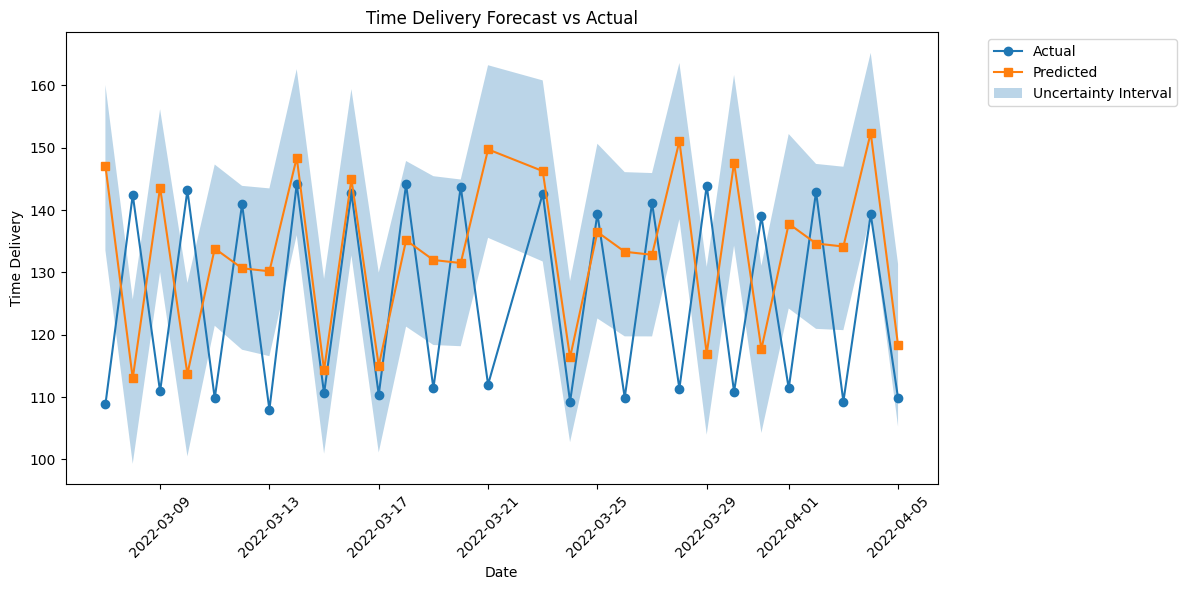

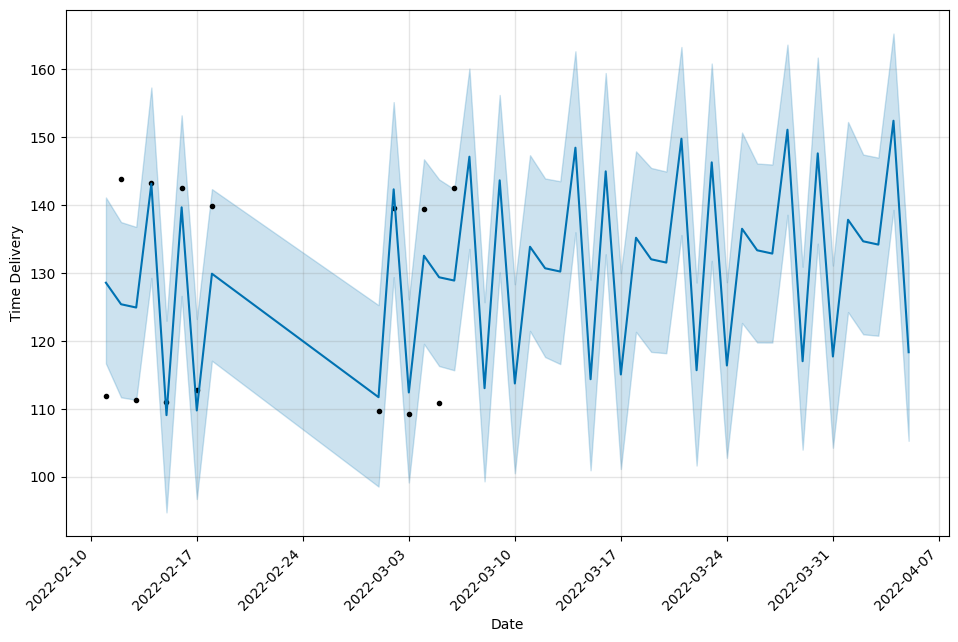

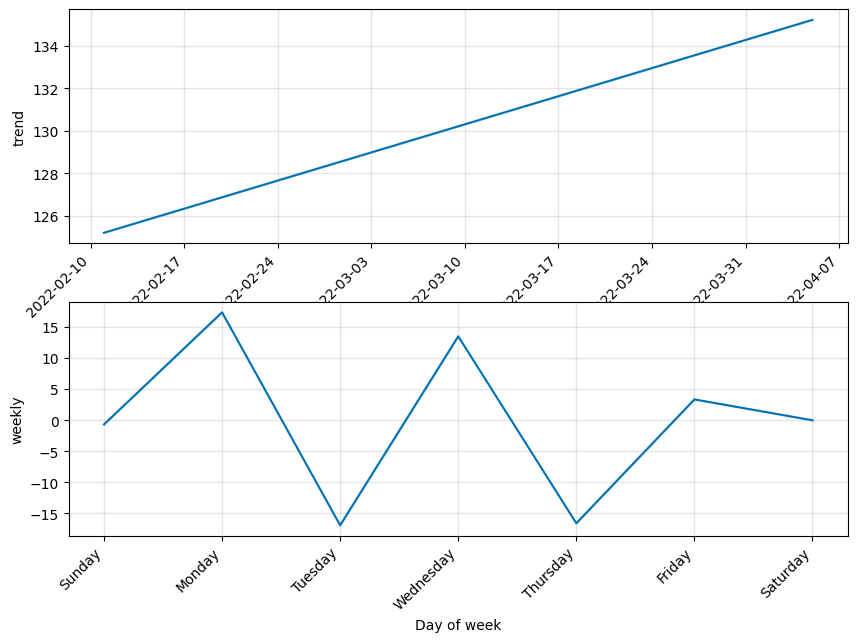

In [184]:
# Calculate error metrics for test period
test_results = results[results['ds'].isin(test_df['ds'])]
test_results = test_results.dropna(subset=['y'])

# if not test_results.empty:
mae = mean_absolute_error(test_results['y'], test_results['yhat'])
mse = mean_squared_error(test_results['y'], test_results['yhat'])
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test_results['y'] - test_results['yhat']) / test_results['y'])) * 100


print(f"Error Metrics:")
print("*" * 90)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(test_results['ds'], test_results['y'], label='Actual', marker='o')
plt.plot(test_results['ds'], test_results['yhat'], label='Predicted', marker='s')
plt.fill_between(test_results['ds'], test_results['yhat_lower'], test_results['yhat_upper'],
                alpha=0.3, label='Uncertainty Interval')
plt.title(f'Time Delivery Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Time Delivery')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

figure1 = model.plot(forecast, xlabel='Date', ylabel='Time Delivery')
figure2 = model.plot_components(forecast)
# Apply rotation to both figures
for fig in [figure1, figure2]:
    # Get all axes from the figure
    axes = fig.get_axes()
    for ax in axes:
        # Rotate x-axis labels
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')  # Optional: set horizontal alignment for better readability

plt.show()

#return store_sales, forecast

Your model predictions are fairly close to actual observations with around 18 units average error.

The presence of some larger individual errors is indicated by RMSE being somewhat higher than MAE.

The error size relative to actual values is about 15%, which may be reasonable or high depending on your application context.



In [226]:
X_test

,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_year,order_month,Pickup_Hours,pickup_hours,Distance_km,distance_km,traffic_encoded,area_encoded,cat_Apparel,cat_Books,cat_Clothing,cat_Cosmetics,cat_Electronics,cat_Grocery,cat_Home,cat_Jewelry,cat_Kitchen,cat_Outdoors,cat_Pet Supplies,cat_Shoes,cat_Skincare,cat_Snacks,cat_Sports,cat_Toys
8268,39,4.9,30.340722,78.060221,30.350722,78.070221,2022,2,0.166667,0.166667,1.468765,1.468765,2,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3100,24,4.9,13.066762,80.251865,13.156762,80.341865,2022,3,0.083333,0.083333,13.969535,13.969535,1,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
23021,23,4.0,21.157729,72.768726,21.237729,72.848726,2022,4,0.250000,0.250000,12.162116,12.162116,1,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
27066,21,4.6,19.875522,75.367127,19.885522,75.377127,2022,2,0.250000,0.250000,1.526395,1.526395,0,0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
38620,29,2.6,0.000000,0.000000,0.080000,0.080000,2022,3,0.166667,0.166667,12.580268,12.580268,2,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3734,31,4.7,18.514210,73.838429,18.594210,73.918429,2022,3,0.083333,0.083333,12.257688,12.257688,3,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
22618,36,4.1,11.006686,76.951736,11.116686,77.061736,2022,3,0.083333,0.083333,17.137936,17.137936,3,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
22308,35,4.8,21.157729,72.768726,21.287729,72.898726,2022,3,0.250000,0.250000,19.761880,19.761880,3,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
7529,38,4.9,19.131141,72.813074,19.141140,72.823074,2022,4,0.083333,0.083333,1.529623,1.529623,2,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [227]:
import pandas as pd

# Append X_TEST below X_TRAIN (stacking them vertically)
X = pd.concat([X_train, X_test], axis=0)

# Optional: Reset the index of the new full DataFrame
X = X.reset_index(drop=True)

In [228]:
X

,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_year,order_month,Pickup_Hours,pickup_hours,Distance_km,distance_km,traffic_encoded,area_encoded,cat_Apparel,cat_Books,cat_Clothing,cat_Cosmetics,cat_Electronics,cat_Grocery,cat_Home,cat_Jewelry,cat_Kitchen,cat_Outdoors,cat_Pet Supplies,cat_Shoes,cat_Skincare,cat_Snacks,cat_Sports,cat_Toys
0,37,4.6,19.876994,75.372353,19.886994,75.382353,2022,2,0.166667,0.166667,1.526388,1.526388,2,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,22,4.7,0.000000,0.000000,0.070000,0.070000,2022,2,0.166667,0.166667,11.007735,11.007735,3,3,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,33,3.5,23.359407,85.325055,23.489407,85.455055,2022,4,0.250000,0.250000,19.618631,19.618631,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,35,4.5,22.320000,73.170000,22.400000,73.250000,2022,4,0.166667,0.166667,12.116559,12.116559,1,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,37,5.0,0.000000,0.000000,0.070000,0.070000,2022,2,0.166667,0.166667,11.007735,11.007735,1,3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43589,31,4.7,18.514210,73.838429,18.594210,73.918429,2022,3,0.083333,0.083333,12.257688,12.257688,3,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
43590,36,4.1,11.006686,76.951736,11.116686,77.061736,2022,3,0.083333,0.083333,17.137936,17.137936,3,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
43591,35,4.8,21.157729,72.768726,21.287729,72.898726,2022,3,0.250000,0.250000,19.761880,19.761880,3,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
43592,38,4.9,19.131141,72.813074,19.141140,72.823074,2022,4,0.083333,0.083333,1.529623,1.529623,2,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [230]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessed data shape:", X_scaled.shape)
print("Features used:", X.columns)

Preprocessed data shape: (43594, 30)
Features used: Index(['agent_age', 'agent_rating', 'store_latitude', 'store_longitude',
       'drop_latitude', 'drop_longitude', 'order_year', 'order_month',
       'Pickup_Hours', 'pickup_hours', 'Distance_km', 'distance_km',
       'traffic_encoded', 'area_encoded', 'cat_Apparel', 'cat_Books',
       'cat_Clothing', 'cat_Cosmetics', 'cat_Electronics', 'cat_Grocery',
       'cat_Home', 'cat_Jewelry', 'cat_Kitchen', 'cat_Outdoors',
       'cat_Pet Supplies', 'cat_Shoes', 'cat_Skincare', 'cat_Snacks',
       'cat_Sports', 'cat_Toys'],
      dtype='object')


In [231]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

In [232]:
print("Dataset shape:", df.shape)
print("\nDataset info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (43594, 26)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 43594 entries, 36718 to 28480
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype          
---  ------           --------------  -----          
 0   agent_age        43594 non-null  int64          
 1   agent_rating     43594 non-null  float64        
 2   store_latitude   43594 non-null  float64        
 3   store_longitude  43594 non-null  float64        
 4   drop_latitude    43594 non-null  float64        
 5   drop_longitude   43594 non-null  float64        
 6   order_date       43594 non-null  datetime64[ns] 
 7   order_time       43594 non-null  timedelta64[ns]
 8   pickup_time      43594 non-null  timedelta64[ns]
 9   weather          43594 non-null  object         
 10  traffic          43594 non-null  object         
 11  vehicle          43594 non-null  object         
 12  area             43594 non-null  object         
 13  delivery_time    43594 non-null  in

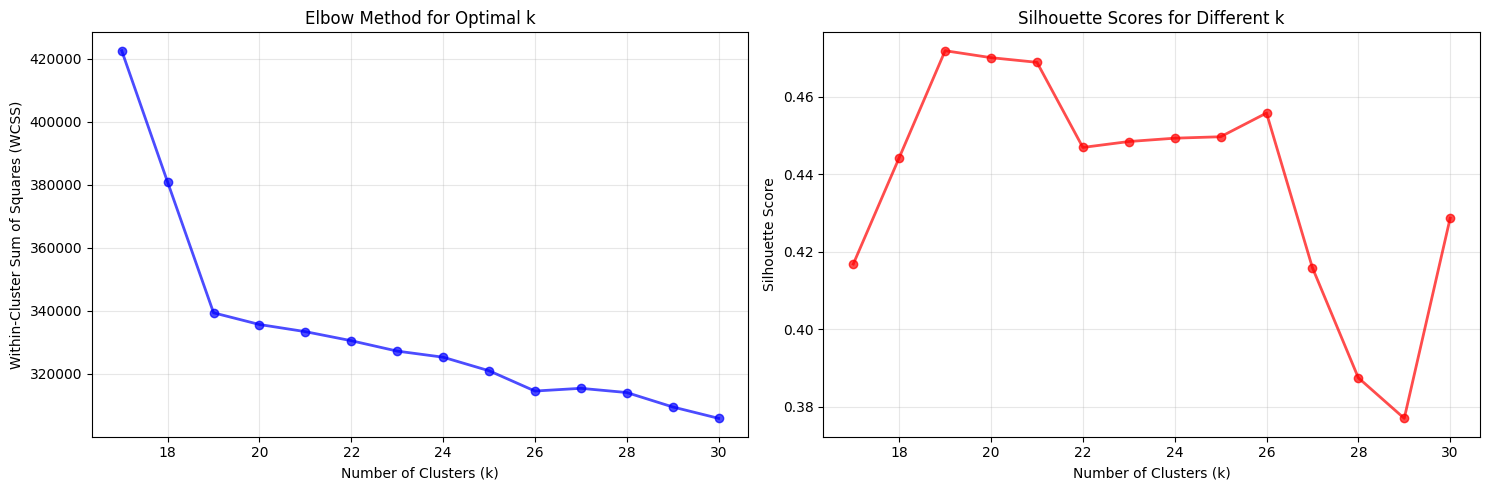

Optimal k based on silhouette score: 4


In [235]:
def plot_elbow_and_silhouette(X_scaled, max_k=30):
    wcss = []  # Within-cluster sum of squares
    silhouette_scores = []
    k_range = range(17, max_k + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Elbow method
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)

        # Silhouette score
        if k > 1:  # Silhouette score requires at least 2 clusters
            score = silhouette_score(X_scaled, kmeans.labels_)
            silhouette_scores.append(score)

    # Plot elbow curve
    ax1.plot(k_range, wcss, 'bo-', alpha=0.7, linewidth=2, markersize=6)
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
    ax1.set_title('Elbow Method for Optimal k')
    ax1.grid(True, alpha=0.3)

    # Plot silhouette scores
    ax2.plot(range(17, max_k + 1), silhouette_scores, 'ro-', alpha=0.7, linewidth=2, markersize=6)
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('Silhouette Scores for Different k')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Find optimal k based on silhouette score
    optimal_k_silhouette = np.argmax(silhouette_scores) + 2  # +2 because we start from k=2
    print(f"Optimal k based on silhouette score: {optimal_k_silhouette}")

    return optimal_k_silhouette, wcss, silhouette_scores

optimal_k, wcss, silhouette_scores = plot_elbow_and_silhouette(X_scaled)